# **Property Prices vs. Education Quality in Manchester**

# Introduction
This project aims to explore the relationship between property prices and education quality in Manchester, including control variables such as socioeconomic deprivation and distance to the city centre as well. It will also briefly investigate the effect of having a school within the area on property prices as opposed to not having a nearby school.

In [1]:
# Importing libraries

import pandas as pd
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import ezodf
from shapely.geometry import Point
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data Sources
There are five main datasets that will be used in this project, namely:
- **Price Paid Data:** Dataset containing residential property transaction data across England and Wales.
- **Five-Year Ofsted Inspection Data:** Dataset containing inspection results and ratings of educational institutes across England.
- **ONS Postcode Directory (August 2025):** Dataset containing postcodes and their geographic coordinates.
- **English Indices of Deprivation 2025:** Dataset containing measures of deprivation across areas in England.
- **Middle layer Super Output Areas (December 2021) Boundaries EW BGC (V3):** Dataset containing the geographic boundaries of Middle layer Super Output Areas (MSOAs) in the UK.

## Price Paid Data
This dataset, provided by the UK HM Land Registry, provides data for the dependent variable (property prices in Manchester). The key variables used include:
- Transaction Unique Identifier
- Price
- Date of Transfer
- Property Type (Detached, Semi-Detached, Terraced, Flats/Maisonettes, Other)
- Property Condition (Old, New)
- Duration (Freehold, Leasehold)
- Postcode

In [2]:
# Listing transaction datasets across 2020-2024

transaction_datasets = [
    '../data/raw/transactions_2020.csv',
    '../data/raw/transactions_2021.csv',
    '../data/raw/transactions_2022.csv',
    '../data/raw/transactions_2023.csv',
    '../data/raw/transactions_2024.csv',
]

Since the data comes in separate CSV files containing yearly property transaction data, the files will be made into a list to simplify the dataset-loading process using a loop.

In [3]:
# Defining column names for transaction datasets

transaction_headers = [
    'Transaction Unique Identifier',
    'Price',
    'Date of Transfer',
    'Postcode',
    'Property Type',
    'Old/New',
    'Duration',
    'PAON',
    'SAON',
    'Street',
    'Locality',
    'Town/City',
    'District',
    'County',
    'PPD Category Type',
    'Record Status'
]

The CSV files do not contain headers, so they must be specified according to the column names in the dataset's website.

In [4]:
# Reading the property transaction datasets into a list

transaction_list = [pd.read_csv(dataset, header=None, names=transaction_headers) for dataset in transaction_datasets]

A ```for``` loop is used to loop through the dataset list to simplify the dataset-loading process. The DataFrames of each dataset will be made into a list before concatenating them into one DataFrame.

In [5]:
# Merging all datasets together into one dataframe

df_transactions = pd.concat(transaction_list, axis=0, ignore_index=True)

df_transactions

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,29,NaN,LINKHAY ORCHARD,SOUTH CHARD,CHARD,SOMERSET,SOMERSET,A,A
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,5,NaN,SOUTHOVER,NaN,WELLS,SOMERSET,SOMERSET,A,A
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,CHRISTCHURCH COURT,FLAT 4,SOUTH STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,8,NaN,HERMITAGE STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A


The DataFrame list is concatenated together into one large DataFrame containing property transaction data from 2020-2024.

In [6]:
# Inspecting data types in df_transactions

df_transactions.dtypes

Transaction Unique Identifier    object
Price                             int64
Date of Transfer                 object
Postcode                         object
Property Type                    object
Old/New                          object
Duration                         object
PAON                             object
SAON                             object
Street                           object
Locality                         object
Town/City                        object
District                         object
County                           object
PPD Category Type                object
Record Status                    object
dtype: object

## Five-Year Ofsted Inspection Data
This dataset, provided by the Office for Standards in Education (Ofsted), provides data for the main independent variable (education quality in Manchester). The key variables used include:
- As At Date
- Postcode
- Overall Effectiveness (1-4)

In [7]:
# Reading the Ofsted school inspection dataset and converting it into a Pandas DataFrame

sheet_schools = ezodf.opendoc('../data/raw/schools.ods').sheets[2] # Selecting the third sheet which contains the data

rows_schools = list(sheet_schools.rows())
headers_schools = [cell.value for cell in rows_schools[2]] # Obtaining column names from row index 2
records_schools = rows_schools[3:] # Obtaining data records from row index 3 onwards

data_schools = []
for record in records_schools:
    values = [cell.value for cell in record] # Extracting values to append into the list
    data_schools.append(values)

df_schools = pd.DataFrame(data_schools, columns=headers_schools) # Converting the list into a Pandas DataFrame

df_schools

,URN,Name,Five-Year Ofsted Inspection Data publish date,Publication type,Remit,As at date,Published date,Government office region,Local authority area,Constituency,...,Category of concern,Effectiveness of leadership and management,Quality of education,Personal development,Behaviour and attitudes,Safeguarding is effective?,Early years provision (where applicable),Sixth form provision (where applicable),Does the inspection relate to the URN of the current school?,None
0,100000.0,The Aldgate School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-11T00:00:00,London,City of London,Cities of London and Westminster,...,None,1.0,1.0,1.0,1.0,Yes,2.0,9.0,Yes,None
1,100005.0,Thomas Coram Centre,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2014-07-02T00:00:00,London,Camden,Holborn and St Pancras,...,None,1.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
2,100006.0,Heath School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-04T00:00:00,London,Camden,Hampstead and Highgate,...,None,1.0,2.0,1.0,1.0,Yes,9.0,9.0,Yes,None
3,100007.0,Camden Primary Pupil Referral Unit,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2015-05-05T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
4,100008.0,Argyle Primary School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2022-11-17T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,2.0,1.0,2.0,Yes,2.0,9.0,Yes,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131924,148026.0,"St Antony's Roman Catholic School, a Voluntary...",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-28T00:00:00,North West,Trafford,Stretford and Urmston,...,SWK,4.0,3.0,2.0,2.0,Yes,9.0,9.0,No,None
131925,148036.0,Gloucester Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-05-29T00:00:00,South West,Gloucestershire,Gloucester,...,SM,4.0,9.0,9.0,9.0,No,9.0,3.0,No,None
131926,148039.0,Northbrook Primary Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-18T00:00:00,North West,Lancashire,South Ribble,...,SM,4.0,4.0,4.0,4.0,Yes,3.0,9.0,No,None
131927,148050.0,"St Monica's RC High School, a Voluntary Academy",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-12-19T00:00:00,North West,Bury,Bury South,...,None,3.0,3.0,3.0,3.0,Yes,9.0,9.0,No,None


Since the dataset is an ODS file, the ```ezodf``` library will be used to read the dataset and select the sheet where the data is stored. Then, the rows of the dataset will be obtained in order to be able to select the row index of the columns and records in the dataset and obtain them. For every data record, the values will be obtained and appended into a list. This list will then be converted into a DataFrame along with the obtained column names.

In [8]:
# Inspecting data types in df_schools

df_schools.dtypes

URN                                                             float64
Name                                                             object
Five-Year Ofsted Inspection Data publish date                    object
Publication type                                                 object
Remit                                                            object
As at date                                                       object
Published date                                                   object
Government office region                                         object
Local authority area                                             object
Constituency                                                     object
Postcode                                                         object
Provider type                                                    object
Provision type                                                   object
Phase                                                           

## ONS Postcode Directory (ONSPD) August 2025
This dataset, provided by the Office for National Statistics (ONS), will be used to aggregate data together at the MSOA level. The key variables used include:
- Postcode
- Local Authority District Code
- Latitude
- Longitude
- LSOA Code
- MSOA Code

In [9]:
# Reading the ONS Postcode Directory dataset

df_onspd = pd.read_csv('../data/raw/onspd.csv')

df_onspd

,pcd7,pcd8,pcds,dointr,doterm,cty25cd,ced25cd,lad25cd,wd25cd,parncp25cd,...,lep21cd1,lep21cd2,pfa23cd,imd20ind,cal24cd,icb23cd,oa21cd,lsoa21cd,msoa21cd,ruc21ind
0,M1 1AA,M1 1AA,M1 1AA,199507,200904.0,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,13409,E56000032,E54000057,E00180796,E01033651,E02006902,UN1
1,M1 1AD,M1 1AD,M1 1AD,200303,NaN,E99999999,E99999999,E08000003,E05011361,E43000157,...,E37000015,NaN,E23000005,12008,E56000032,E54000057,E00175827,E01033658,E02006902,UN1
2,M1 1AE,M1 1AE,M1 1AE,200501,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00176052,E01034129,E02006912,UN1
3,M1 1AF,M1 1AF,M1 1AF,200506,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,8141,E56000032,E54000057,E00175961,E01033653,E02006912,UN1
4,M1 1AG,M1 1AG,M1 1AG,201003,202501.0,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59993,M99 1ZU,M99 1ZU,M99 1ZU,200701,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
59994,M99 1ZW,M99 1ZW,M99 1ZW,200405,NaN,E99999999,E99999999,E08000003,E05011361,E43000157,...,E37000015,NaN,E23000005,12008,E56000032,E54000057,E00175827,E01033658,E02006902,UN1
59995,M99 2BE,M99 2BE,M99 2BE,200604,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
59996,M99 2BS,M99 2BS,M99 2BS,200604,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1


Since this dataset is a CSV file, it can be easily loaded using ```pd.read_csv()```.

In [10]:
# Inspecting data types in df_onspd

df_onspd.dtypes

pcd7           object
pcd8           object
pcds           object
dointr          int64
doterm        float64
cty25cd        object
ced25cd        object
lad25cd        object
wd25cd         object
parncp25cd     object
usrtypind       int64
east1m        float64
north1m       float64
gridind         int64
hlth19cd       object
nhser24cd      object
ctry25cd       object
rgn25cd        object
ssr95cd        object
pcon24cd       object
eer20cd        object
educ23cd       object
ttwa15cd       object
pco19cd        object
itl25cd        object
wdstl05cd      object
oa01cd         object
wdcas03cd      object
npark16cd      object
lsoa01cd       object
msoa01cd       object
ruc01ind       object
oac01ind       object
oa11cd         object
lsoa11cd       object
msoa11cd       object
wz11cd         object
sicbl24cd      object
bua24cd        object
ruc11ind       object
oac11ind       object
lat           float64
long          float64
lep21cd1       object
lep21cd2      float64
pfa23cd   

## English Indices of Deprivation 2025
This dataset, provided by the Ministry of Housing, Communities and Local Government (MHCLG), serves as a control variable to consider socioeconomic differences between areas. The key variables used include:
- LSOA Code
- Local Authority District Code
- IMD Rank
- IMD Decile

In [11]:
# Reading the IMD dataset

df_imd = pd.read_excel('../data/raw/imd.xlsx', sheet_name='IMD25')

df_imd

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4
...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,27536,9
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,27902,9
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,27532,9
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,28981,9


Since this dataset is an XLSX file, ```pd.read_excel()``` will be used to load the dataset in order to select the sheet where the data is stored.

In [12]:
# Inspecting data types in df_transactions

df_imd.dtypes

LSOA code (2021)                                                                    object
LSOA name (2021)                                                                    object
Local Authority District code (2024)                                                object
Local Authority District name (2024)                                                object
Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)                  int64
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA     int64
dtype: object

## Middle-Layer Super Output Area Boundaries
This dataset, provided by the Office for National Statistics (ONS), will be used to enable spatial mapping of property transactions, education quality, and deprivation of areas across Manchester. The key variables used include:
- MSOA Code
- Geometry

In [13]:
# Reading the MSOA Boundaries dataset

gdf_msoa = gpd.read_file('../data/raw/msoa_boundaries.geojson')

gdf_msoa

,FID,MSOA21CD,MSOA21NM,MSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E02000001,City of London 001,,532384,181355,51.51562,-0.093490,71249043-b176-4306-ba6c-d1a993b1b741,"POLYGON ((-0.09676 51.52325, -0.09644 51.52282..."
1,2,E02000002,Barking and Dagenham 001,,548267,189685,51.58652,0.138756,997a80a8-0ebe-461c-91eb-3e4122571a6e,"POLYGON ((0.14811 51.59678, 0.14809 51.5964, 0..."
2,3,E02000003,Barking and Dagenham 002,,548259,188520,51.57606,0.138149,62ded9d9-f53a-454d-af35-04404d9dbe9b,"POLYGON ((0.15065 51.58306, 0.14841 51.58075, ..."
3,4,E02000004,Barking and Dagenham 003,,551004,186412,51.55639,0.176828,511181cd-e71f-4c63-81ee-e8e76744a627,"POLYGON ((0.18511 51.5648, 0.18403 51.56391, 0..."
4,5,E02000005,Barking and Dagenham 004,,548733,186824,51.56069,0.144267,b0c823eb-69e0-4ae7-9e1c-37715cf3fe87,"POLYGON ((0.14991 51.56807, 0.15078 51.56778, ..."
...,...,...,...,...,...,...,...,...,...,...
7259,7260,W02000424,Wrexham 021,Wrecsam 021,335589,355197,53.09010,-2.963220,d42ac770-ac81-4883-b475-dad3fb302924,"POLYGON ((-3.00773 53.1095, -3.00671 53.10925,..."
7260,7261,W02000425,Wrexham 022,Wrecsam 022,337505,353566,53.07567,-2.934290,728d3024-3caa-4bc6-84a8-6a0118a516d8,"POLYGON ((-2.96016 53.13248, -2.95817 53.13041..."
7261,7262,W02000426,Wrexham 023,Wrecsam 023,334766,351723,53.05877,-2.974800,777609dd-352d-4f22-81f6-3fde80d4a17d,"POLYGON ((-2.98809 53.04753, -2.99166 53.04678..."
7262,7263,W02000427,Neath Port Talbot 021,Castell-nedd Port Talbot 021,287336,198958,51.67806,-3.630870,f8192bda-7e6b-4dba-9eaa-b2c6320eb547,"POLYGON ((-3.71463 51.72705, -3.70742 51.72553..."


Since this dataset is a GeoJSON file, ```gpd.read_file()``` must be used to correctly load the dataset.

In [14]:
# Inspecting data types in gdf_msoa

gdf_msoa.dtypes

FID             int32
MSOA21CD       object
MSOA21NM       object
MSOA21NMW      object
BNG_E           int32
BNG_N           int32
LAT           float64
LONG          float64
GlobalID       object
geometry     geometry
dtype: object

# Data Preprocessing
This section involves many data preprocessing subsections, namely:
- Standardising Postcode Formats
- Column Selection
- Merging ONSPD Data into Transaction and School Data
- Filtering Manchester-Based Data Records
- Reviewing Data Types
- Standardising Date Formats
- Ensuring Temporal Alignment
- Aggregating Data into the MSOA Level
- Handling Missing Ofsted Data
- Calculating Distance to the City Centre
- Cleaning the Final Dataset
- Reviewing Data in the Final Dataset

The final result at the end of this section will be a finalised dataset suitable for Exploratory Data Analysis (EDA) and modelling.

## Standardising Postcode Formats
This process involves standardising postcode formats across the datasets in order to prevent any mismatches in postcode formats when merging datasets together.

In [15]:
# Function to standardise postcode formats

def standardise_postcode(df, col):
    df[col] = (df[col].astype(str).str.upper().str.strip()) # Ensures that all postcodes are strings, all uppercase, and does not have unnecessary whitespace
    df = df[df[col].notna()] # Removes NaN postcodes
    df = df[df[col] != ''] # Removes empty postcodes

    postcode_regex = r'^[A-Z]{1,2}[0-9][0-9A-Z]?\s?[0-9][A-Z]{2}' # Specifies the standard format for UK postcodes
    df = df[df[col].str.match(postcode_regex)]

    return df

The function to standardise postcode formats involves ensuring that every postcode are strings, has all-uppercase letters, and does not contain any unnecessary whitespace. The function will also remove NaN and empty postcodes from the dataset. Afterwards, the standard UK postcode format will be specified in order to match every postcode in the dataset with it. This ensures that each and every postcode in each dataset have the same format.

In [16]:
# Standardising postcodes in df_transactions

df_transactions_standardised = standardise_postcode(df_transactions, 'Postcode')

df_transactions_standardised

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,29,NaN,LINKHAY ORCHARD,SOUTH CHARD,CHARD,SOMERSET,SOMERSET,A,A
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,5,NaN,SOUTHOVER,NaN,WELLS,SOMERSET,SOMERSET,A,A
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,CHRISTCHURCH COURT,FLAT 4,SOUTH STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,8,NaN,HERMITAGE STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A


In [17]:
# Standardising postcodes in df_schools

df_schools_standardised = standardise_postcode(df_schools, 'Postcode')

df_schools_standardised

,URN,Name,Five-Year Ofsted Inspection Data publish date,Publication type,Remit,As at date,Published date,Government office region,Local authority area,Constituency,...,Category of concern,Effectiveness of leadership and management,Quality of education,Personal development,Behaviour and attitudes,Safeguarding is effective?,Early years provision (where applicable),Sixth form provision (where applicable),Does the inspection relate to the URN of the current school?,None
0,100000.0,The Aldgate School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-11T00:00:00,London,City of London,Cities of London and Westminster,...,None,1.0,1.0,1.0,1.0,Yes,2.0,9.0,Yes,None
1,100005.0,Thomas Coram Centre,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2014-07-02T00:00:00,London,Camden,Holborn and St Pancras,...,None,1.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
2,100006.0,Heath School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-04T00:00:00,London,Camden,Hampstead and Highgate,...,None,1.0,2.0,1.0,1.0,Yes,9.0,9.0,Yes,None
3,100007.0,Camden Primary Pupil Referral Unit,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2015-05-05T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
4,100008.0,Argyle Primary School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2022-11-17T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,2.0,1.0,2.0,Yes,2.0,9.0,Yes,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131923,148024.0,The New Forest Church of England Primary School,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-09-12T00:00:00,South West,Wiltshire,Salisbury,...,None,3.0,9.0,9.0,9.0,Yes,3.0,9.0,No,None
131924,148026.0,"St Antony's Roman Catholic School, a Voluntary...",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-28T00:00:00,North West,Trafford,Stretford and Urmston,...,SWK,4.0,3.0,2.0,2.0,Yes,9.0,9.0,No,None
131925,148036.0,Gloucester Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-05-29T00:00:00,South West,Gloucestershire,Gloucester,...,SM,4.0,9.0,9.0,9.0,No,9.0,3.0,No,None
131926,148039.0,Northbrook Primary Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-18T00:00:00,North West,Lancashire,South Ribble,...,SM,4.0,4.0,4.0,4.0,Yes,3.0,9.0,No,None


## Column Selection
This process involves selecting important/relevant columns from each dataset to improve the simplicity and visibility of each dataset.

In [18]:
# Defines important columns in each dataset

transaction_cols = [
    'Transaction Unique Identifier',
    'Price',
    'Date of Transfer',
    'Postcode',
    'Property Type',
    'Old/New',
    'Duration'
]

school_cols = [
    'URN',
    'As at date',
    'Postcode',
    'Phase',
    'Overall effectiveness'
]

onspd_cols = [
    'pcds',
    'lad25cd',
    'lat',
    'long',
    'lsoa21cd',
    'msoa21cd'
]

imd_cols = [
    'LSOA code (2021)',
    'Local Authority District code (2024)',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'
]

The important columns of each dataset is made into lists to simplify the process of column-filtering for each dataset.

In [19]:
# Filtering important columns in df_transactions_standardised

df_transactions_filtered = df_transactions_standardised[transaction_cols]

df_transactions_filtered

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F
...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F


In [20]:
# Filtering important columns in df_schools_standardised

df_schools_filtered = df_schools_standardised[school_cols]

df_schools_filtered

,URN,As at date,Postcode,Phase,Overall effectiveness
0,100000.0,2024-12-31T00:00:00,EC3A 5DE,Primary,1.0
1,100005.0,2024-12-31T00:00:00,WC1N 2NY,Nursery,1.0
2,100006.0,2024-12-31T00:00:00,NW3 2NY,PRU,2.0
3,100007.0,2024-12-31T00:00:00,NW1 3EX,PRU,2.0
4,100008.0,2024-12-31T00:00:00,WC1H 9EG,Primary,2.0
...,...,...,...,...,...
131923,148024.0,2020-08-31T00:00:00,SP5 2BY,Primary,3.0
131924,148026.0,2020-08-31T00:00:00,M41 9PD,Secondary,4.0
131925,148036.0,2020-08-31T00:00:00,GL4 6RN,Secondary,4.0
131926,148039.0,2020-08-31T00:00:00,PR25 2GB,Primary,4.0


In [21]:
# Filtering important columns in df_onspd

df_onspd_filtered = df_onspd[onspd_cols]

df_onspd_filtered

,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
0,M1 1AA,E08000003,53.487378,-2.227194,E01033651,E02006902
1,M1 1AD,E08000003,53.483829,-2.244852,E01033658,E02006902
2,M1 1AE,E08000003,53.483487,-2.231182,E01034129,E02006912
3,M1 1AF,E08000003,53.480563,-2.237148,E01033653,E02006912
4,M1 1AG,E08000003,53.483298,-2.231452,E01034129,E02006912
...,...,...,...,...,...,...
59993,M99 1ZU,E08000003,53.483009,-2.232264,E01034129,E02006912
59994,M99 1ZW,E08000003,53.487374,-2.242687,E01033658,E02006902
59995,M99 2BE,E08000003,53.483009,-2.232264,E01034129,E02006912
59996,M99 2BS,E08000003,53.483009,-2.232264,E01034129,E02006912


In [22]:
# Filtering important columns in df_imd

df_imd_filtered = df_imd[imd_cols]

df_imd_filtered

,LSOA code (2021),Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,E09000001,26525,8
1,E01000002,E09000001,31203,10
2,E01000003,E09000001,25913,8
3,E01000005,E09000001,14807,5
4,E01000006,E09000002,10917,4
...,...,...,...,...
33750,E01035758,E07000180,27536,9
33751,E01035759,E07000180,27902,9
33752,E01035760,E07000180,27532,9
33753,E01035761,E07000180,28981,9


## Merging ONSPD Data into Transaction and School Data
This process involves merging the ONSPD dataset into the property transaction and school inspection datasets to assign each property and each school to their respective postcode and postcode's respective geographic coordinates and LAD/LSOA/MSOA codes.

In [23]:
# Merging df_onspd_filtered into df_transactions_standardised

df_transactions_merged = df_transactions_filtered.merge(df_onspd_filtered, left_on='Postcode', right_on='pcds', how='left')

df_transactions_merged

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,NaN,NaN,NaN,NaN,NaN,NaN
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,NaN,NaN,NaN,NaN,NaN,NaN
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,NaN,NaN,NaN,NaN,NaN,NaN
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5007096,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN
5007097,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,NaN,NaN,NaN,NaN,NaN,NaN
5007098,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,NaN,NaN,NaN,NaN,NaN,NaN
5007099,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# Merging df_onspd_filtered into df_schools_standardised

df_schools_merged = df_schools_filtered.merge(df_onspd_filtered, left_on='Postcode', right_on='pcds', how='left')

df_schools_merged

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
0,100000.0,2024-12-31T00:00:00,EC3A 5DE,Primary,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,100005.0,2024-12-31T00:00:00,WC1N 2NY,Nursery,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,100006.0,2024-12-31T00:00:00,NW3 2NY,PRU,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,100007.0,2024-12-31T00:00:00,NW1 3EX,PRU,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100008.0,2024-12-31T00:00:00,WC1H 9EG,Primary,2.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
131923,148024.0,2020-08-31T00:00:00,SP5 2BY,Primary,3.0,NaN,NaN,NaN,NaN,NaN,NaN
131924,148026.0,2020-08-31T00:00:00,M41 9PD,Secondary,4.0,M41 9PD,E08000009,53.449131,-2.334575,E01006156,E02001266
131925,148036.0,2020-08-31T00:00:00,GL4 6RN,Secondary,4.0,NaN,NaN,NaN,NaN,NaN,NaN
131926,148039.0,2020-08-31T00:00:00,PR25 2GB,Primary,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Confirming df_transactions_merged merge success by finding the number of records with an M-postcode (records with a non-null 'pcds' value)

df_transactions_merged['pcds'].isna().value_counts()

pcds
True     4904338
False     102763
Name: count, dtype: int64

Merging the ONSPD data into the property transaction dataset has been successful, where there are 102763 property transactions based in areas with an M postcode.

In [26]:
# Confirming df_schools_merged merge success by finding the number of records with an M-postcode (records with a non-null 'pcds' value)

df_schools_merged['pcds'].isna().value_counts()

pcds
True     129155
False      2773
Name: count, dtype: int64

Merging the ONSPD data into the school inspection dataset has been successful, where there are 2773 school inspections based in areas with an M postcode.

## Filtering Manchester-Based Data Records
This process involves filtering the property transaction and school inspection datasets by the Local Authority District (LAD) code E08000003, which is the LAD code for Manchester City.

In [27]:
# Filtering Manchester-based records in df_transactions_merged

df_transactions_manchester = df_transactions_merged[df_transactions_merged['lad25cd'] == 'E08000003']

df_transactions_manchester

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
748,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27 00:00,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E02001056
1332,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21 00:00,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E02006916
1334,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02 00:00,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E02001073
2490,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18 00:00,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E02001082
2496,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18 00:00,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E02001089
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5006261,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01 00:00,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E02001083
5006317,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05 00:00,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E02001073
5006325,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28 00:00,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E02001046
5006343,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26 00:00,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E02006986


In [28]:
# Filtering Manchester-based records in df_schools_merged

df_schools_manchester = df_schools_merged[df_schools_merged['lad25cd'] == 'E08000003']

df_schools_manchester

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
2208,105384.0,2024-12-31T00:00:00,M15 6PA,Nursery,1.0,M15 6PA,E08000003,53.466270,-2.242597,E01005210,E02001063
2209,105385.0,2024-12-31T00:00:00,M40 7QD,Nursery,1.0,M40 7QD,E08000003,53.494858,-2.221461,E01005130,E02006902
2210,105387.0,2024-12-31T00:00:00,M40 7PR,Primary,1.0,M40 7PR,E08000003,53.490731,-2.226911,E01005130,E02006902
2211,105389.0,2024-12-31T00:00:00,M19 2PF,Primary,2.0,M19 2PF,E08000003,53.441491,-2.192310,E01005221,E02001075
2212,105397.0,2024-12-31T00:00:00,M8 4NB,Primary,2.0,M8 4NB,E08000003,53.531647,-2.244917,E01005160,E02001048
...,...,...,...,...,...,...,...,...,...,...,...
130355,145622.0,2020-08-31T00:00:00,M8 8SA,Primary,2.0,M8 8SA,E08000003,53.503502,-2.232693,E01033676,E02006913
130549,145845.0,2020-08-31T00:00:00,M12 4GR,Special,4.0,M12 4GR,E08000003,53.451288,-2.181121,E01005200,E02006986
130566,145873.0,2020-08-31T00:00:00,M21 7AA,Secondary,None,M21 7AA,E08000003,53.435545,-2.264792,E01005156,E02001077
130837,146227.0,2020-08-31T00:00:00,M40 0BX,Primary,2.0,M40 0BX,E08000003,53.507998,-2.179388,E01005248,E02001049


In [29]:
# Finding missing values in the 'Overall effectiveness' column from df_schools_manchester

df_schools_manchester['Overall effectiveness'].unique()

array([1.0, 2.0, 'Not judged', 3.0, 4.0, None], dtype=object)

The ```Overall effectiveness``` column in the school inspection dataset contains ```None``` and/or unspecified scores.

In [30]:
# Converting unjudged overall effectiveness values into None values

df_schools_manchester['Overall effectiveness'] = df_schools_manchester['Overall effectiveness'].replace('Not judged', None)

df_schools_manchester['Overall effectiveness'].unique()

C:\Users\Nitro\AppData\Local\Temp\ipykernel_45244\3149210945.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_schools_manchester['Overall effectiveness'] = df_schools_manchester['Overall effectiveness'].replace('Not judged', None)


array([1.0, 2.0, None, 3.0, 4.0], dtype=object)

To handle ```None``` and/or unspecified values, the unspecified but non-null values will first be converted into ```None``` values to make it easier to remove them.

In [31]:
# Removing None overall effectiveness values

df_schools_manchester = df_schools_manchester.dropna(subset=['Overall effectiveness'])

df_schools_manchester['Overall effectiveness'].unique()

array([1.0, 2.0, 3.0, 4.0], dtype=object)

The ```None``` scores have been removed and the column is now suitable to be aggregated to the MSOA level.

## Reviewing Data Types
While this process does not involve any alterations to the datasets, it is still good practice to review the data types present in the main datasets to familiarise oneself on the nature of the data.

In [32]:
# Reviewing the datatypes of df_transactions_manchester

df_transactions_manchester.dtypes

Transaction Unique Identifier     object
Price                              int64
Date of Transfer                  object
Postcode                          object
Property Type                     object
Old/New                           object
Duration                          object
pcds                              object
lad25cd                           object
lat                              float64
long                             float64
lsoa21cd                          object
msoa21cd                          object
dtype: object

In [33]:
# Reviewing the datatypes of df_schools_manchester

df_schools_manchester.dtypes

URN                      float64
As at date                object
Postcode                  object
Phase                     object
Overall effectiveness     object
pcds                      object
lad25cd                   object
lat                      float64
long                     float64
lsoa21cd                  object
msoa21cd                  object
dtype: object

## Standardising Date Formats
This process involves standardising the formats of date columns in each main dataset into the ```YYYY-MM-DD``` format to be able to easily verify the data's temporal alignment in the next process.

In [34]:
# Converting the 'Date of Transfer' column from df_transactions_manchester to datetime

df_transactions_manchester['Date of Transfer'] = pd.to_datetime(df_transactions_manchester['Date of Transfer'])

df_transactions_manchester

C:\Users\Nitro\AppData\Local\Temp\ipykernel_45244\1890003870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transactions_manchester['Date of Transfer'] = pd.to_datetime(df_transactions_manchester['Date of Transfer'])


,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
748,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E02001056
1332,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E02006916
1334,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E02001073
2490,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E02001082
2496,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E02001089
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5006261,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E02001083
5006317,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E02001073
5006325,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E02001046
5006343,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E02006986


In [35]:
# Converting the 'As at date' column from df_schools_manchester to datetime

df_schools_manchester['As at date'] = pd.to_datetime(df_schools_manchester['As at date'])

df_schools_manchester

C:\Users\Nitro\AppData\Local\Temp\ipykernel_45244\1030539751.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_schools_manchester['As at date'] = pd.to_datetime(df_schools_manchester['As at date'])


,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
2208,105384.0,2024-12-31,M15 6PA,Nursery,1.0,M15 6PA,E08000003,53.466270,-2.242597,E01005210,E02001063
2209,105385.0,2024-12-31,M40 7QD,Nursery,1.0,M40 7QD,E08000003,53.494858,-2.221461,E01005130,E02006902
2210,105387.0,2024-12-31,M40 7PR,Primary,1.0,M40 7PR,E08000003,53.490731,-2.226911,E01005130,E02006902
2211,105389.0,2024-12-31,M19 2PF,Primary,2.0,M19 2PF,E08000003,53.441491,-2.192310,E01005221,E02001075
2212,105397.0,2024-12-31,M8 4NB,Primary,2.0,M8 4NB,E08000003,53.531647,-2.244917,E01005160,E02001048
...,...,...,...,...,...,...,...,...,...,...,...
130224,145439.0,2020-08-31,M14 7FB,Primary,2.0,M14 7FB,E08000003,53.446731,-2.237458,E01005178,E02001074
130355,145622.0,2020-08-31,M8 8SA,Primary,2.0,M8 8SA,E08000003,53.503502,-2.232693,E01033676,E02006913
130549,145845.0,2020-08-31,M12 4GR,Special,4.0,M12 4GR,E08000003,53.451288,-2.181121,E01005200,E02006986
130837,146227.0,2020-08-31,M40 0BX,Primary,2.0,M40 0BX,E08000003,53.507998,-2.179388,E01005248,E02001049


## Ensuring Temporal Alignment
This process involves verifying the temporal alignment of each main dataset (records must be within the years 2020-2024). Additionally, duplicate school inspection records (e.g. one school having multiple inspections) will be removed and the latest record will be maintained in the dataset.

In [36]:
# Verifying the temporal alignment of df_transactions_manchester

df_transactions_manchester['Date of Transfer'].dt.year.between(2020, 2024).unique()

array([ True])

In [37]:
# Ensuring that each school has its latest inspection

df_schools_manchester = df_schools_manchester.sort_values(['As at date', 'URN']).groupby('URN', as_index=False).tail(1)

df_schools_manchester

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd
112531,105525.0,2020-08-31,M8 0SP,Primary,4.0,M8 0SP,E08000003,53.500946,-2.238694,E01005147,E02006915
112558,105577.0,2020-08-31,M40 0EW,Secondary,4.0,M40 0EW,E08000003,53.518186,-2.176339,E01005250,E02001049
90516,105555.0,2021-08-31,M9 8BG,Primary,1.0,M9 8BG,E08000003,53.518348,-2.214676,E01005206,E02001050
100345,135875.0,2021-08-31,M23 9BP,Secondary,4.0,M23 9BP,E08000003,53.402132,-2.296305,E01005117,E02001092
104631,141392.0,2021-08-31,M23 2SX,Secondary,4.0,M23 2SX,E08000003,53.382906,-2.288834,E01005075,E02001095
...,...,...,...,...,...,...,...,...,...,...,...
21568,150600.0,2024-12-31,M40 7EJ,Primary,3.0,M40 7EJ,E08000003,53.488577,-2.210457,E01005132,E02006983
21574,150612.0,2024-12-31,M13 9UJ,Primary,3.0,M13 9UJ,E08000003,53.469802,-2.224540,E01005065,E02001062
21599,150650.0,2024-12-31,M12 5LZ,Primary,4.0,M12 5LZ,E08000003,53.469559,-2.187993,E01005186,E02001064
21627,150693.0,2024-12-31,M22 5AU,Primary,4.0,M22 5AU,E08000003,53.379400,-2.244870,E01005292,E02001096


## Aggregating Data into the MSOA Level
This process involves aggregating the data into the MSOA level in order to ensure that data on school inspections and other variables are as complete as possible for each area in Manchester (aggregating at the LSOA level means that many LSOAs may not have relevant school inspection data), while maintaining data granularity.

In [38]:
# Verifying that no null MSOAs exist in df_schools_manchester

df_schools_manchester['msoa21cd'].isna().sum()

0

In [39]:
# Grouping df_schools_manchester by average overall effectiveness/score per MSOA

df_msoa_ofsted = df_schools_manchester.groupby('msoa21cd', as_index=False)['Overall effectiveness'].mean().rename(columns={'Overall effectiveness': 'mean_ofsted_score'})

df_msoa_ofsted

,msoa21cd,mean_ofsted_score
0,E02001045,1.714286
1,E02001046,2.0
2,E02001047,2.428571
3,E02001048,2.0
4,E02001049,3.0
5,E02001050,1.75
6,E02001051,3.0
7,E02001052,2.0
8,E02001053,2.0
9,E02001055,2.0


In [40]:
# Aligning the LSOA column name format in df_imd_filtered with the MSOA column name format in df_msoa_ofsted

df_imd_filtered = df_imd_filtered.rename(columns={'LSOA code (2021)': 'lsoa21cd'})

df_imd_filtered

,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,E09000001,26525,8
1,E01000002,E09000001,31203,10
2,E01000003,E09000001,25913,8
3,E01000005,E09000001,14807,5
4,E01000006,E09000002,10917,4
...,...,...,...,...
33750,E01035758,E07000180,27536,9
33751,E01035759,E07000180,27902,9
33752,E01035760,E07000180,27532,9
33753,E01035761,E07000180,28981,9


In [41]:
# Merging ONSPD LSOA and MSOA codes into df_imd_filtered

df_imd_merged = df_imd_filtered.merge(df_onspd_filtered[['lsoa21cd', 'msoa21cd']], on='lsoa21cd', how='left')

df_imd_merged

,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,msoa21cd
0,E01000001,E09000001,26525,8,NaN
1,E01000002,E09000001,31203,10,NaN
2,E01000003,E09000001,25913,8,NaN
3,E01000005,E09000001,14807,5,NaN
4,E01000006,E09000002,10917,4,NaN
...,...,...,...,...,...
92635,E01035758,E07000180,27536,9,NaN
92636,E01035759,E07000180,27902,9,NaN
92637,E01035760,E07000180,27532,9,NaN
92638,E01035761,E07000180,28981,9,NaN


In [42]:
# Aggregating IMD into the MSOA level

df_imd_msoa = df_imd_merged.groupby('msoa21cd', as_index=False).agg(mean_imd_rank = ('Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'mean'),
                                                                    mean_imd_decile = ('Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA', 'mean'))

df_imd_msoa

,msoa21cd,mean_imd_rank,mean_imd_decile
0,E02001007,12877.000000,4.000000
1,E02001009,16941.000000,6.000000
2,E02001013,29004.000000,9.000000
3,E02001017,19617.641026,6.423077
4,E02001027,3743.000000,2.000000
...,...,...,...
169,E02006963,24511.290749,7.740088
170,E02006983,3945.190171,1.608974
171,E02006984,8496.675000,2.966667
172,E02006985,1166.336000,1.000000


In [43]:
# Merging df_msoa_ofsted into the IMD dataset 

df_msoa_ofsted_imd = df_imd_msoa.merge(df_msoa_ofsted, on='msoa21cd', how='left')

df_msoa_ofsted_imd

,msoa21cd,mean_imd_rank,mean_imd_decile,mean_ofsted_score
0,E02001007,12877.000000,4.000000,NaN
1,E02001009,16941.000000,6.000000,NaN
2,E02001013,29004.000000,9.000000,NaN
3,E02001017,19617.641026,6.423077,NaN
4,E02001027,3743.000000,2.000000,NaN
...,...,...,...,...
169,E02006963,24511.290749,7.740088,NaN
170,E02006983,3945.190171,1.608974,2.5
171,E02006984,8496.675000,2.966667,2.0
172,E02006985,1166.336000,1.000000,2.0


In [44]:
# Merging df_msoa_ofsted_imd into df_transactions_manchester

df_final = df_transactions_manchester.merge(df_msoa_ofsted_imd, on='msoa21cd', how='left')

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd,mean_imd_rank,mean_imd_decile,mean_ofsted_score
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E02001056,846.172308,1.000000,1.75
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E02006916,9873.392157,3.122549,2.0
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E02001073,16278.518293,5.382114,2.0
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E02001082,17196.066465,5.407855,1.666667
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E02001089,23583.510086,7.576369,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E02001083,20285.456446,6.564460,2.0
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E02001073,16278.518293,5.382114,2.0
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E02001046,3320.306843,1.461369,2.0
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E02006986,3706.956897,1.818966,1.0


## Handling Missing Ofsted Data
This process involves handling missing school inspection data in the final dataset, as there may be concerns that there are still some MSOAs with no relevant school inspection data. A new variable, school presence (```no_school_msoa``` where ```1``` stands for MSOAs with absence of relevant school inspection data and ```0``` stands for MSOAs with relevant school inspection data) will be created, and the model will be split into two: one for the main model and the other accounting for school presence.

In [45]:
# Checking the percentage of missing 'mean_score' values in df_final

df_final['mean_ofsted_score'].isna().mean() * 100

11.586420549890281

In [46]:
# Creating a column to indicate whether the MSOA the transaction was based in has a school within it

df_final['no_school_msoa'] = df_final['mean_ofsted_score'].isna().astype(int)

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd,mean_imd_rank,mean_imd_decile,mean_ofsted_score,no_school_msoa
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E02001056,846.172308,1.000000,1.75,0
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E02006916,9873.392157,3.122549,2.0,0
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E02001073,16278.518293,5.382114,2.0,0
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E02001082,17196.066465,5.407855,1.666667,0
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E02001089,23583.510086,7.576369,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E02001083,20285.456446,6.564460,2.0,0
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E02001073,16278.518293,5.382114,2.0,0
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E02001046,3320.306843,1.461369,2.0,0
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E02006986,3706.956897,1.818966,1.0,0


## Calculating Distance to the City Centre

This process involves creating the column for the control variable of distance to the city centre. However, taking into consideration the Earth's spherical nature, the Haversine distance for every property transaction to the city centre must be calculated.

### Calculating the Haversine distance

The formula to calculate the Haversine distance is shown below.

$$
d = 2R \arcsin \left(\sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta \lambda}{2}\right)}\right)
$$

Where
- $d$: Haversine distance
- $R$: Radius of the spherical base (in this case, Earth's radius)
- $\phi_1, \phi_2$: Latitudes of point 1 and 2 (in this case, the property's and Manchester city centre's latitude)
- $\Delta \phi$: Latitude difference
- $\Delta \lambda$: Longitude difference

In [47]:
# Function to calculate the Haversine distance between two points

def haversine_distance(lat1, long1, lat2, long2, radius):
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2]) # Converting degrees into radians

    lat_distance = lat2 - lat1
    long_distance = long2 - long1

    angular_separation = np.sin(lat_distance / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(long_distance / 2)**2 # Calculating the haversine formula component measuring the angular separation between two points on a spherical surface

    central_angle = 2 * np.arcsin(np.sqrt(angular_separation)) # Calculating the central angle between the two points

    return radius * central_angle

In [48]:
# Defining the coordinates of Manchester's city centre (Manchester City Council) and Earth's radius

CITY_CENTRE_LAT = 53.47896767366295
CITY_CENTRE_LONG = -2.2439974214337894
EARTH_RADIUS_KM = 6371

In [49]:
# Calculating the distance between each property transaction and Manchester's city centre

df_final['distance_to_city_centre_km'] = haversine_distance(df_final['lat'], df_final['long'], CITY_CENTRE_LAT, CITY_CENTRE_LONG, EARTH_RADIUS_KM)

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,msoa21cd,mean_imd_rank,mean_imd_decile,mean_ofsted_score,no_school_msoa,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E02001056,846.172308,1.000000,1.75,0,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E02006916,9873.392157,3.122549,2.0,0,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E02001073,16278.518293,5.382114,2.0,0,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E02001082,17196.066465,5.407855,1.666667,0,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E02001089,23583.510086,7.576369,2.0,0,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E02001083,20285.456446,6.564460,2.0,0,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E02001073,16278.518293,5.382114,2.0,0,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E02001046,3320.306843,1.461369,2.0,0,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E02006986,3706.956897,1.818966,1.0,0,5.069080


## Cleaning the Final Dataset
This process involves cleaning the final dataset, which includes dropping redundant columns, standardising and reordering columns, sorting the data, and exporting the final, processed dataset.

In [50]:
# Dropping redundant columns

df_final = df_final.drop(columns=['pcds', 'lad25cd'])

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,lat,long,lsoa21cd,msoa21cd,mean_imd_rank,mean_imd_decile,mean_ofsted_score,no_school_msoa,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,53.496830,-2.188129,E01005261,E02001056,846.172308,1.000000,1.75,0,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,53.475279,-2.262702,E01033673,E02006916,9873.392157,3.122549,2.0,0,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,53.441642,-2.279734,E01005150,E02001073,16278.518293,5.382114,2.0,0,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,53.434101,-2.232872,E01005274,E02001082,17196.066465,5.407855,1.666667,0,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,53.403338,-2.221227,E01005171,E02001089,23583.510086,7.576369,2.0,0,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,53.431187,-2.247365,E01033671,E02001083,20285.456446,6.564460,2.0,0,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,53.447577,-2.278357,E01005159,E02001073,16278.518293,5.382114,2.0,0,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,53.522021,-2.211603,E01034108,E02001046,3320.306843,1.461369,2.0,0,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,53.446672,-2.189954,E01005199,E02006986,3706.956897,1.818966,1.0,0,5.069080


In [51]:
# Standardising column names and reordering them

df_final = df_final.rename(columns = {
    'Transaction Unique Identifier': 'transaction_id',
    'Price': 'price',
    'Date of Transfer': 'transfer_date',
    'Postcode': 'postcode',
    'Property Type': 'property_type',
    'Old/New': 'property_condition',
    'Duration': 'duration',
    'lat': 'latitude',
    'long': 'longitude',
    'lsoa21cd': 'lsoa_code',
    'msoa21cd': 'msoa_code',
    'mean_ofsted_score': 'msoa_ofsted_score',
    'mean_imd_rank': 'msoa_imd_rank',
    'mean_imd_decile': 'msoa_imd_decile'
})[
    [
        'transaction_id',
        'price',
        'transfer_date',
        'property_type',
        'property_condition',
        'duration',
        'postcode',
        'latitude',
        'longitude',
        'lsoa_code',
        'msoa_code',
        'no_school_msoa',
        'msoa_ofsted_score',
        'msoa_imd_rank',
        'msoa_imd_decile',
        'distance_to_city_centre_km'
    ]
]

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,T,N,F,M40 2SZ,53.496830,-2.188129,E01005261,E02001056,0,1.75,846.172308,1.000000,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,F,N,L,M3 4AZ,53.475279,-2.262702,E01033673,E02006916,0,2.0,9873.392157,3.122549,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,F,N,L,M21 9HP,53.441642,-2.279734,E01005150,E02001073,0,2.0,16278.518293,5.382114,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,T,N,F,M20 3FF,53.434101,-2.232872,E01005274,E02001082,0,1.666667,17196.066465,5.407855,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,S,N,L,M20 5PW,53.403338,-2.221227,E01005171,E02001089,0,2.0,23583.510086,7.576369,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,T,N,F,M20 1QH,53.431187,-2.247365,E01033671,E02001083,0,2.0,20285.456446,6.564460,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,T,N,F,M21 9QJ,53.447577,-2.278357,E01005159,E02001073,0,2.0,16278.518293,5.382114,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,D,N,F,M9 7AB,53.522021,-2.211603,E01034108,E02001046,0,2.0,3320.306843,1.461369,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,T,N,F,M19 3DF,53.446672,-2.189954,E01005199,E02006986,0,1.0,3706.956897,1.818966,5.069080


In [52]:
# Sorting the dataset by the date of transfer and transaction unique identifier

df_final = df_final.sort_values(['transfer_date', 'transaction_id']).reset_index(drop=True)

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,E02001087,0,1.666667,26170.139785,8.439068,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,E02001064,0,2.25,2297.263547,1.000000,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,E02001084,0,2.0,18866.597059,5.952941,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,E02001084,0,2.0,18866.597059,5.952941,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,E02001061,0,1.75,2038.727960,1.166247,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,E02001050,0,1.75,1789.622472,1.000000,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,E02001075,0,2.0,3837.892655,1.344633,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,E02006912,0,1.0,14591.828313,4.837349,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,E02006917,1,NaN,18251.694215,5.657025,0.533760


In [53]:
# Exporting the final processed dataset

df_final.to_csv('../data/processed/final_dataset.csv')

## Reviewing Data in the Final Dataset
This process involves conducting a final review on the processed dataset, including inspecting the data types and missing values within it.

In [54]:
# Checking dataset structure and missing values

df_final.info()
df_final.isna().mean().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38735 entries, 0 to 38734
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   transaction_id              38735 non-null  object        
 1   price                       38735 non-null  int64         
 2   transfer_date               38735 non-null  datetime64[ns]
 3   property_type               38735 non-null  object        
 4   property_condition          38735 non-null  object        
 5   duration                    38735 non-null  object        
 6   postcode                    38735 non-null  object        
 7   latitude                    38735 non-null  float64       
 8   longitude                   38735 non-null  float64       
 9   lsoa_code                   38735 non-null  object        
 10  msoa_code                   38735 non-null  object        
 11  no_school_msoa              38735 non-null  int32     

msoa_ofsted_score             0.115864
transaction_id                0.000000
price                         0.000000
transfer_date                 0.000000
property_type                 0.000000
property_condition            0.000000
duration                      0.000000
postcode                      0.000000
latitude                      0.000000
longitude                     0.000000
lsoa_code                     0.000000
msoa_code                     0.000000
no_school_msoa                0.000000
msoa_imd_rank                 0.000000
msoa_imd_decile               0.000000
distance_to_city_centre_km    0.000000
dtype: float64

Based on the output above, ```msoa_ofsted_score``` is a column of the ```object``` data type, which will introduce issues in the Exploratory Data Analysis and the modelling phase. Converting it into numeric data will make it easier to analyse and model with this variable.

Next, only ```msoa_ofsted_score``` has missing values which most likely stems from some MSOAs not having relevant school inspection data. This has been handled by introducing the school presence variable (```no_school_msoa```).

In [55]:
# Converting the mean Ofsted score for the MSOA of the property transaction from object into numeric

df_final['msoa_ofsted_score'] = pd.to_numeric(df_final['msoa_ofsted_score'], errors='coerce')

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,E02001087,0,1.666667,26170.139785,8.439068,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,E02001064,0,2.250000,2297.263547,1.000000,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,E02001084,0,2.000000,18866.597059,5.952941,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,E02001084,0,2.000000,18866.597059,5.952941,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,E02001061,0,1.750000,2038.727960,1.166247,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,E02001050,0,1.750000,1789.622472,1.000000,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,E02001075,0,2.000000,3837.892655,1.344633,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,E02006912,0,1.000000,14591.828313,4.837349,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,E02006917,1,NaN,18251.694215,5.657025,0.533760


# Exploratory Data Analysis (EDA)
This section involves displaying statistics for each of the main variables, as well as analyse them and their relationships through a wide range of visuals.

This section will include:
- Statistics and visuals of variables and bivariate relationships
- Correlations between variables
- Geographic choropleth maps of how different variables vary across Manchester

## Property Price
This subsection will include displaying the descriptive statistics and distribution of property prices in Manchester to review the nature of this variable's data.

### Descriptive Statistics for Property Prices
Reviewing the descriptive statistics for property prices is useful for identifying the nature of the variable's data.

In [56]:
# Displaying the descriptive statistics of property prices

df_final['price'].describe()

count    3.873500e+04
mean     3.381010e+05
std      2.039407e+06
min      1.000000e+02
25%      1.600000e+05
50%      2.272900e+05
75%      3.200000e+05
max      2.920000e+08
Name: price, dtype: float64

The ```mean``` is shown to be higher than the median/```50%``` which indicates the presence of right-skewness in the data. Additionally, there is a large difference between the ```min``` and the ```max``` as well as a large value for the standard deviation (```std```), meaning that the data demonstrates high variation.

### Distribution of Raw Property Prices
The distribution of raw property prices will be visualised which will help verify the findings from reviewing the descriptive statistics.

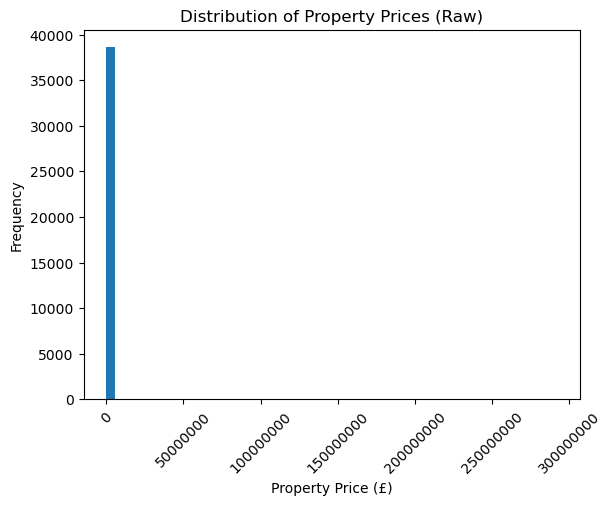

In [57]:
# Plotting the distribution of raw property prices

plt.figure()
plt.hist(df_final['price'], bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Property Price (£)')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices (Raw)')
plt.show()

The heavily right-skewed, high-variation distribution of raw property prices above indicates that outliers exist.

### Solving Property Price Outliers
Outliers are present in the raw property price data, which affects its visualisation as demonstrated earlier, as well as the linear regression later on. Therefore, log-transforming the data is required to stabilise the distribution and remove outliers.

In [58]:
# Checking for any property price outliers

df_final.sort_values('price', ascending=False)

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
16846,{E53EDD2E-ABFE-83EC-E053-6B04A8C03A59},292000000,2021-12-17,O,N,L,M3 3AQ,53.480414,-2.253286,E01033681,E02006917,1,NaN,18251.694215,5.657025,0.635344
16255,{D707E536-74F6-0AD9-E053-6B04A8C067CC},86691213,2021-11-30,O,N,F,M1 2AR,53.474890,-2.228770,E01033654,E02006912,0,1.000000,14591.828313,4.837349,1.105018
27879,{152AB734-7891-E651-E063-4704A8C061D9},85700000,2023-06-20,O,N,F,M1 2DH,53.475105,-2.229208,E01033654,E02006912,0,1.000000,14591.828313,4.837349,1.068819
10536,{C8A3A576-F463-0425-E053-6C04A8C0947B},82000000,2021-04-09,O,N,L,M15 4RP,53.472669,-2.247440,E01033656,E02006914,0,2.000000,17832.829653,5.728707,0.736504
26693,{FAC30767-CCBF-5E20-E053-4704A8C004EE},75000000,2023-03-29,O,N,F,M3 2WY,53.481430,-2.248846,E01033658,E02006902,0,1.333333,12846.010173,4.345541,0.421787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24743,{152AB734-8383-E651-E063-4704A8C061D9},135,2022-12-05,O,N,F,M21 9FZ,53.439547,-2.287353,E01005155,E02001081,0,1.666667,20657.082192,6.842466,5.239552
2164,{BA558B33-7BFB-76EF-E053-6B04A8C0B4B7},120,2020-03-31,O,N,L,M13 0EH,53.460061,-2.218239,E01034119,E02001066,0,2.000000,5255.089494,2.007782,2.706756
28481,{0B853950-C7C4-69A5-E063-4704A8C07DAC},120,2023-07-20,O,N,F,M20 6RT,53.416954,-2.226383,E01005176,E02001087,0,1.666667,26170.139785,8.439068,6.993571
6362,{E2D14906-7542-4C2D-E053-6B04A8C0422B},115,2020-11-12,O,N,F,M40 7AE,53.490102,-2.207089,E01005132,E02006983,0,2.500000,3945.190171,1.608974,2.737974


As shown above, the property price data contains outliers that will affect the visualisation of the distribution of property prices. Therefore, the prices will need to be log-transformed to stabilise the property price data, and the log-transformed property prices will be used as the dependent variable.

In [59]:
# Log-transforming property prices

df_final.insert(loc=df_final.columns.get_loc('price') + 1, column='log_price', value=np.log(df_final['price']))

df_final

,transaction_id,price,log_price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,13.237476,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,E02001087,0,1.666667,26170.139785,8.439068,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,12.031719,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,E02001064,0,2.250000,2297.263547,1.000000,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,13.758940,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,E02001084,0,2.000000,18866.597059,5.952941,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,12.254863,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,E02001084,0,2.000000,18866.597059,5.952941,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,11.362103,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,E02001061,0,1.750000,2038.727960,1.166247,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,11.901583,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,E02001050,0,1.750000,1789.622472,1.000000,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,12.611538,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,E02001075,0,2.000000,3837.892655,1.344633,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,11.931636,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,E02006912,0,1.000000,14591.828313,4.837349,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,12.968550,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,E02006917,1,NaN,18251.694215,5.657025,0.533760


### Distribution of Log-Transformed Property Prices
The distribution of log-transformed property prices will be visualised to verify the success of log-transformation in stabilising the property price data distribution.

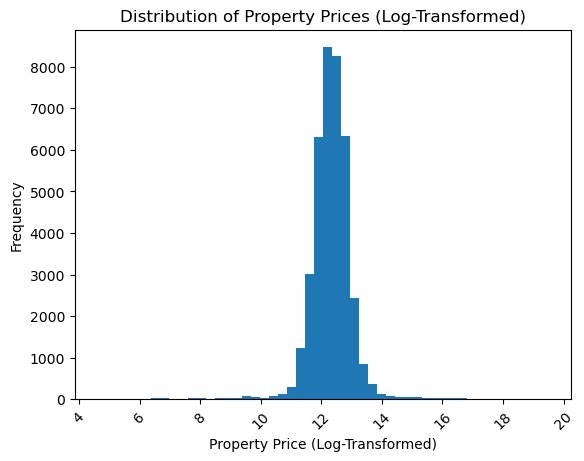

In [60]:
# Plotting the distribution of log-transformed property prices

plt.figure()
plt.hist(df_final['log_price'], bins=50)
plt.xlabel('Property Price (Log-Transformed)')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices (Log-Transformed)')
plt.show()

As displayed above, log-transforming property prices stabilises the distribution of property prices into a usable form for linear regression.

## Ofsted Score
This subsection will focus on school quality in Manchester, measured by the mean overall school inspection score in the respective MSOA. This includes splitting the dataset based on whether the property's MSOA contains any valid school inspection data. Furthermore, the descriptive statistics and distribution of non-null school quality data in Manchester will be displayed to review the nature of this variable's data. Its bivariate relationship with property prices will also be addressed.

### Distinguishing between MSOAs with and without Schools
Some of the school quality data records are missing, which may indicate the absence of valid school inspection data in those respective MSOAs.

In [61]:
# Finding out how common no-school MSOAs are

df_final['no_school_msoa'].value_counts(normalize=True)

no_school_msoa
0    0.884136
1    0.115864
Name: proportion, dtype: float64

Around 11% of the data contains property transactions within MSOAs that have either no schools or no recent school inspections.

### Property Prices by School Presence
The absence of some valid school inspection records may raise a question on whether school presence or the presence of measurable school quality in the MSOA affects property prices.

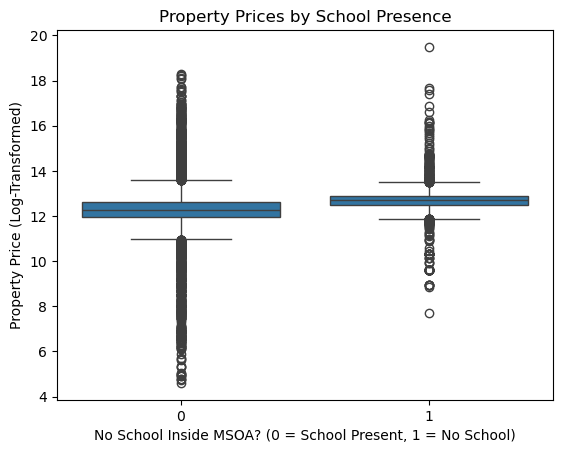

In [62]:
# Plotting property prices by whether there is a school within the MSOA

sns.boxplot(data=df_final, x='no_school_msoa', y='log_price')
plt.xlabel('No School Inside MSOA? (0 = School Present, 1 = No School)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Property Prices by School Presence')
plt.show()

The distribution of property prices in areas with a school differs to that of property prices in areas with no schools/inspections. This implies that the presence of schools in the area also affects property prices. Therefore, to further test this, an additional model will be used to investigate this relationship as well.

### Selecting Data from MSOAs with Valid Ofsted Scores
The ```NaN``` values for the MSOA Ofsted score in some records will be unusable for the main linear regression model, so the data with valid Ofsted scores will be selected to be explored through this data analysis and the modelling phase later on.

In [63]:
# Separating data containing property prices with a school in the area

df_final_with_schools = df_final[df_final['no_school_msoa'] == 0]

df_final_with_schools

,transaction_id,price,log_price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,13.237476,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,E02001087,0,1.666667,26170.139785,8.439068,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,12.031719,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,E02001064,0,2.250000,2297.263547,1.000000,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,13.758940,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,E02001084,0,2.000000,18866.597059,5.952941,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,12.254863,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,E02001084,0,2.000000,18866.597059,5.952941,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,11.362103,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,E02001061,0,1.750000,2038.727960,1.166247,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38728,{44F406B7-3F7C-1095-E063-4704A8C048D4},25000,10.126631,2024-12-20,O,N,L,M14 5TB,53.456722,-2.225616,E01005284,E02001070,0,2.000000,8449.279693,2.961686,2.756641
38729,{2D4D7609-2B20-BDF9-E063-4804A8C0672F},180000,12.100712,2024-12-23,F,N,L,M4 4HB,53.488675,-2.239333,E01033658,E02006902,0,1.333333,12846.010173,4.345541,1.122661
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,11.901583,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,E02001050,0,1.750000,1789.622472,1.000000,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,12.611538,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,E02001075,0,2.000000,3837.892655,1.344633,5.194057


### Descriptive Statistics for Non-Null Ofsted Scores
Reviewing the descriptive statistics for non-null Ofsted scores is useful for identifying the nature of the variable's data.

In [64]:
# Displaying the descriptive statistics for mean Ofsted scores in the MSOA of the property transaction for MSOAs with schools

df_final_with_schools['msoa_ofsted_score'].describe()

count    34247.000000
mean         1.921324
std          0.475604
min          1.000000
25%          1.666667
50%          2.000000
75%          2.000000
max          3.250000
Name: msoa_ofsted_score, dtype: float64

The data demonstrates balanced statistics overall, with the ```mean``` being similar to the median/```50%```, the ```min``` and ```max``` not being too far apart, and the standard deviation (```std```) being low.

### Distribution of Non-Null Ofsted Scores
Visualising the distribution of non-null Ofsted scores will help identify where the data is clustered overall.

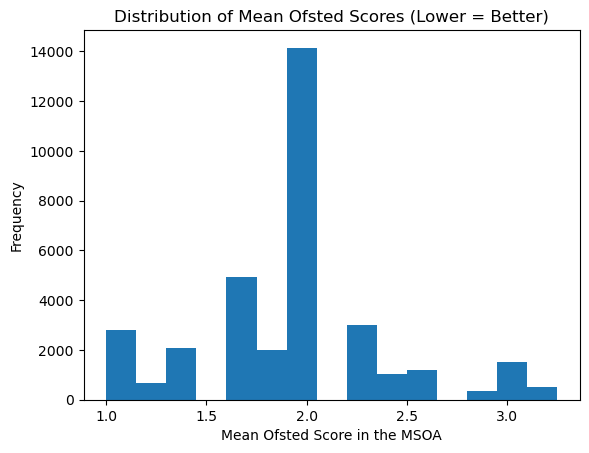

In [65]:
# Plotting the distribution of mean Ofsted scores in the MSOA of each property transaction

plt.hist(df_final_with_schools['msoa_ofsted_score'], bins=15)
plt.xlabel('Mean Ofsted Score in the MSOA')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Ofsted Scores (Lower = Better)')
plt.show()

Based on the finding above, the majority of schools in Manchester can be considered to be generally good, with some of the smaller segments representing outstanding schools or those needing improvement.

### Education Quality vs. Property Prices (for MSOAs with Valid Ofsted Scores)
The bivariate relationship between education quality and property prices in Manchester (for MSOAs with valid Ofsted scores) will be visualised to grasp the general idea regarding their relationship before adding control variables and what to possibly expect from the multiple linear regression modelling in later phases.

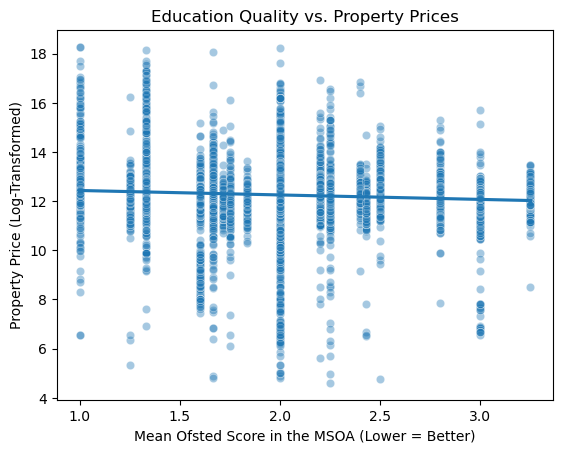

In [66]:
# Plotting the relationship between education quality and property prices in areas with schools

sns.scatterplot(data=df_final_with_schools, x='msoa_ofsted_score', y='log_price', alpha=0.4)
sns.regplot(data=df_final_with_schools, x='msoa_ofsted_score', y='log_price', scatter=False)
plt.xlabel('Mean Ofsted Score in the MSOA (Lower = Better)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Education Quality vs. Property Prices')
plt.show()

Based on the plot above, a slightly negative but weak correlation exists between the average education quality values in the area of the property transaction and property prices (where better schools mean higher property prices), before accounting for control variables such as IMD and distance to the city centre. Additionally, even when education quality is similar, the property prices can still vary greatly. This plot indicates that education quality is one of several factors that affect property prices, and that there may be other variable driving it.

## IMD Rank
This subsection will focus on socioeconomic deprivation indexes across areas in Manchester, measured by the IMD rank per MSOA. The descriptive statistics and distribution of IMD ranks in Manchester will be displayed to review the nature of this variable's data. Its bivariate relationship with property prices will also be addressed.

### Descriptive Statistics for IMD Ranks
Reviewing the descriptive statistics for IMD ranks is useful for identifying the nature of the variable's data.

In [67]:
# Displaying the descriptive statistics for the IMD rank

df_final['msoa_imd_rank'].describe()

count    38735.000000
mean      9951.885493
std       6834.449504
min        404.294118
25%       3893.331111
50%       8496.675000
75%      16278.518293
max      26170.139785
Name: msoa_imd_rank, dtype: float64

The data's descriptive statistics suggest a very diverse range of IMD ranks across areas in Manchester, with the percentiles being far apart, and the standard deviation (```std```) being high.

### Distribution of IMD Ranks
The distribution of IMD ranks will be visualised which will help verify the findings from reviewing the descriptive statistics.

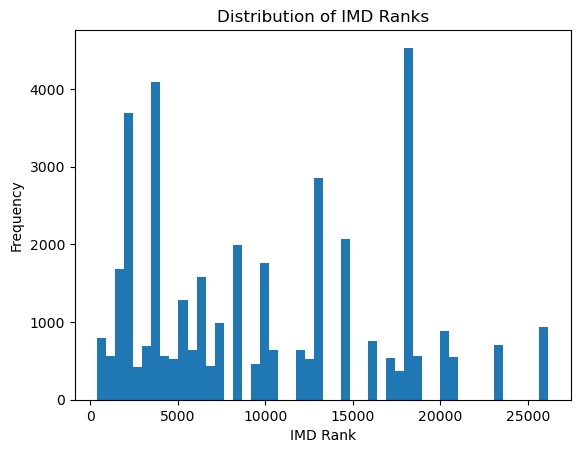

In [68]:
# Plotting the distribution of IMD ranks

plt.hist(df_final['msoa_imd_rank'], bins=50)
plt.xlabel('IMD Rank')
plt.ylabel('Frequency')
plt.title('Distribution of IMD Ranks')
plt.show()

As shown above, the IMD ranks in Manchester can vary greatly, which indicates that Manchester has diverse deprivation levels across its MSOAs.

### Deprivation vs. Property Prices
The bivariate relationship between socioeconomic deprivation levels and property prices in Manchester will be visualised to grasp the general idea regarding their individual relationship before accounting for the rest of the variables and what to possibly expect from the multiple linear regression modelling in later phases where all the variables are accounted for.

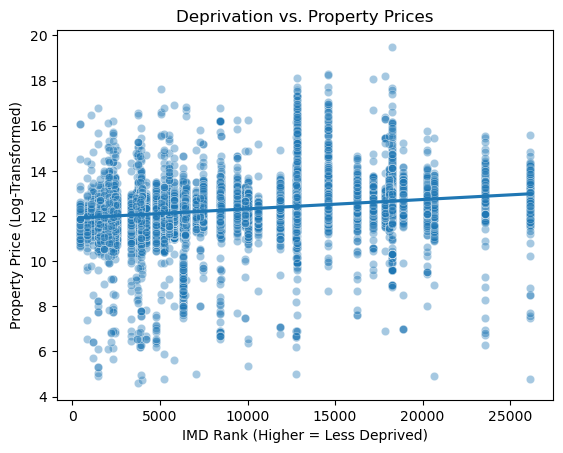

In [69]:
# Plotting the relationship between IMD ranks and property prices

sns.scatterplot(data=df_final, x='msoa_imd_rank', y='log_price', alpha=0.4)
sns.regplot(data=df_final, x='msoa_imd_rank', y='log_price', scatter=False)
plt.xlabel('IMD Rank (Higher = Less Deprived)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Deprivation vs. Property Prices')
plt.show()

The plot above shows that the relationship between IMD ranks and property prices is positive, which is expected for less-deprived areas to have more expensive housing. As a result, this indicates that deprivation can also be one variable to look out for when exploring the relationship between education quality and property prices, so it will be included as one of the control variables in the later regression analysis.

## Distance to the City Centre
This subsection will focus on the variable representing the distance from the property to the city centre. The descriptive statistics and distribution of distance to the city centre will be displayed to review the nature of this variable's data. Its bivariate relationship with property prices will also be addressed.

### Descriptive Statistics for Distance to the City Centre (km)
Reviewing the descriptive statistics for distance to the city centre is useful for identifying the nature of the variable's data.

In [70]:
# Displaying the descriptive statistics for distance to the city centre (km)

df_final['distance_to_city_centre_km'].describe()

count    38735.000000
mean         4.306279
std          2.794073
min          0.068991
25%          1.463279
50%          4.541367
75%          5.867734
max         13.729635
Name: distance_to_city_centre_km, dtype: float64

The data's descriptive statistics suggest that many records are clustered in a certain range of distance to the city centre while still showing high variation, with the ```min``` and ```75%``` being relatively closer while ```75%``` and ```max``` being far apart,, and the standard deviation (```std```) being high.

### Distibution of Distance to the City Centre (km)
The distribution of distance to the city centre will be visualised which will help verify the findings from reviewing the descriptive statistics.

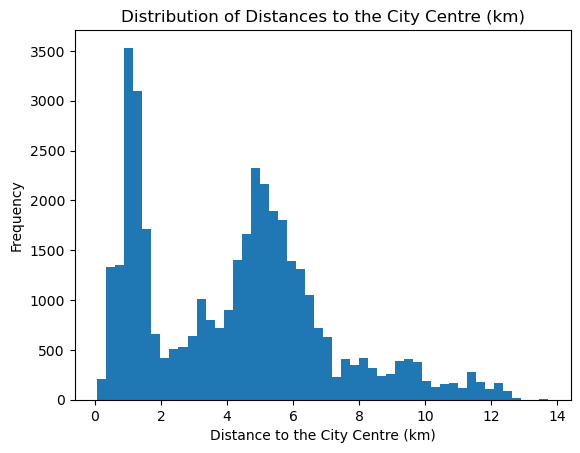

In [71]:
# Plotting the distribution of distances to the city centre (km)

plt.hist(df_final['distance_to_city_centre_km'], bins=50)
plt.xlabel('Distance to the City Centre (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances to the City Centre (km)')
plt.show()

As shown above, the distances to the city centre from the property transaction vary, with the majority of property transactions being relatively close, reflecting the variation in how close houses in Manchester are to the city centre.

### Distance to the City Centre (km) vs. Property Prices
The bivariate relationship between distance to the city centre and property prices in Manchester will be visualised to grasp the general idea regarding their individual relationship before accounting for the rest of the variables and what to possibly expect from the multiple linear regression modelling in later phases where all the variables are accounted for.

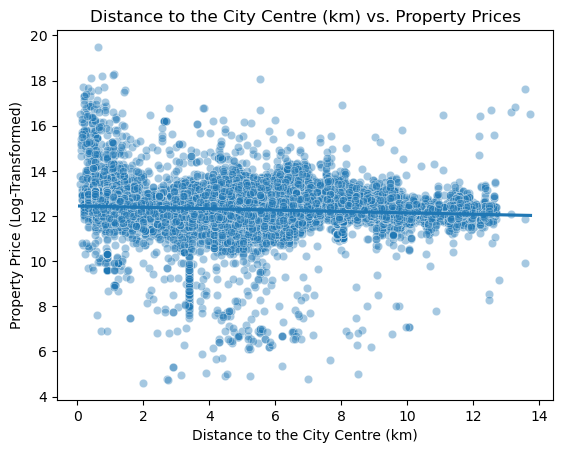

In [72]:
# Plotting the relationship between distance to the city centre (km) and property prices

sns.scatterplot(data=df_final, x='distance_to_city_centre_km', y='log_price', alpha=0.4)
sns.regplot(data=df_final, x='distance_to_city_centre_km', y='log_price', scatter=False)
plt.xlabel('Distance to the City Centre (km)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Distance to the City Centre (km) vs. Property Prices')
plt.show()

Based on the plot above, property prices will tend to decrease as the property's distance to the city centre increases, which highlights the significance of spatial accessibility in a property's valuation.

## Correlation Summary
The correlation matrix below summarises the relationships/correlations between the different variables to be involved in the main multiple linear regression model later on.

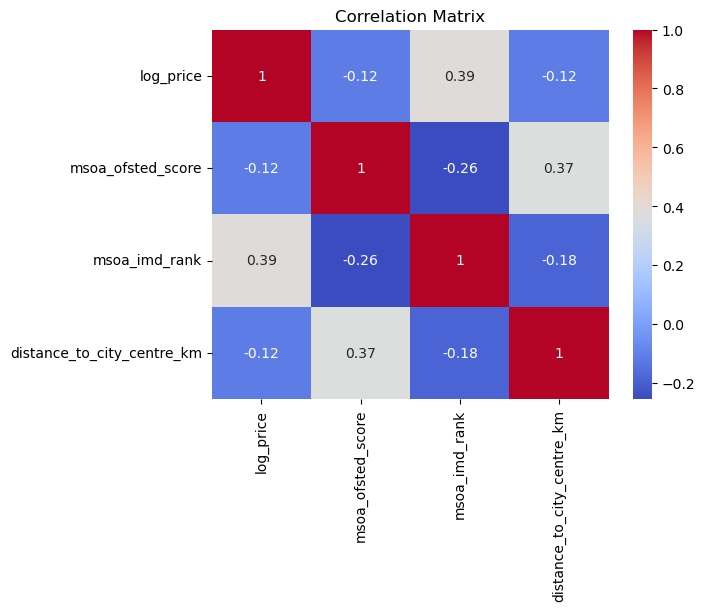

In [73]:
# Summarising correlations between different variables and property prices

correlations = df_final[['log_price', 'msoa_ofsted_score', 'msoa_imd_rank', 'distance_to_city_centre_km']].corr()

sns.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

To summarise the correlations between different variables through the correlation matrix above, there is a weak negative correlation between property prices and education quality (lower score = higher quality = higher prices), followed by a moderate positive correlation between property prices and IMD ranks, and a weak negative correlation between property prices and distance to the city centre. Meanwhile, education quality has a moderate negative correlation with IMD ranks and a moderate positive correlation with distance to the city centre. These correlation patterns, especially regarding education quality having a weaker effect on property prices, reveal that confounding exists between education quality, IMD ranks and distance to the city centre which warrants the use of multivariate regression in order to more-accurately illustrate the relationship between education qualiy and property prices in Manchester.

## Spatial Mapping
This subsection involves visualising the variables into choropleth maps to showcase how they are spread out across different areas in Manchester. This will also help visualise any varying values across the city, one notable exammple is how values of variables may differ depending on how close they are to the city centre.

### Creating a GeoDataFrame for Spatial Mapping
In order to visualise the variables into choropleth maps, the final dataset must be merged into the MSOA boundaries dataset to be able to obtain the geometry of each property's MSOA.

In [74]:
# Creating a temporary GeoDataFrame consisting of df_final combined with gdf_msoa

gdf = gdf_msoa.merge(df_final, left_on='MSOA21CD', right_on='msoa_code', how='left')

gdf

,FID,MSOA21CD,MSOA21NM,MSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,...,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
0,1,E02000001,City of London 001,,532384,181355,51.51562,-0.093490,71249043-b176-4306-ba6c-d1a993b1b741,"POLYGON ((-0.09676 51.52325, -0.09644 51.52282...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,E02000002,Barking and Dagenham 001,,548267,189685,51.58652,0.138756,997a80a8-0ebe-461c-91eb-3e4122571a6e,"POLYGON ((0.14811 51.59678, 0.14809 51.5964, 0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,E02000003,Barking and Dagenham 002,,548259,188520,51.57606,0.138149,62ded9d9-f53a-454d-af35-04404d9dbe9b,"POLYGON ((0.15065 51.58306, 0.14841 51.58075, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,E02000004,Barking and Dagenham 003,,551004,186412,51.55639,0.176828,511181cd-e71f-4c63-81ee-e8e76744a627,"POLYGON ((0.18511 51.5648, 0.18403 51.56391, 0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,E02000005,Barking and Dagenham 004,,548733,186824,51.56069,0.144267,b0c823eb-69e0-4ae7-9e1c-37715cf3fe87,"POLYGON ((0.14991 51.56807, 0.15078 51.56778, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45935,7260,W02000424,Wrexham 021,Wrecsam 021,335589,355197,53.09010,-2.963220,d42ac770-ac81-4883-b475-dad3fb302924,"POLYGON ((-3.00773 53.1095, -3.00671 53.10925,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45936,7261,W02000425,Wrexham 022,Wrecsam 022,337505,353566,53.07567,-2.934290,728d3024-3caa-4bc6-84a8-6a0118a516d8,"POLYGON ((-2.96016 53.13248, -2.95817 53.13041...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45937,7262,W02000426,Wrexham 023,Wrecsam 023,334766,351723,53.05877,-2.974800,777609dd-352d-4f22-81f6-3fde80d4a17d,"POLYGON ((-2.98809 53.04753, -2.99166 53.04678...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45938,7263,W02000427,Neath Port Talbot 021,Castell-nedd Port Talbot 021,287336,198958,51.67806,-3.630870,f8192bda-7e6b-4dba-9eaa-b2c6320eb547,"POLYGON ((-3.71463 51.72705, -3.70742 51.72553...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# Filtering Manchester MSOA codes in gdf

manchester_codes = set(df_final['msoa_code'])
gdf = gdf[gdf['MSOA21CD'].isin(manchester_codes)]

gdf

,FID,MSOA21CD,MSOA21NM,MSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,...,postcode,latitude,longitude,lsoa_code,msoa_code,no_school_msoa,msoa_ofsted_score,msoa_imd_rank,msoa_imd_decile,distance_to_city_centre_km
993,994,E02001045,Manchester 001,,385188,404213,53.53437,-2.22494,f7a445f2-679d-43e4-afb0-821e85398792,"POLYGON ((-2.213 53.54202, -2.21086 53.54075, ...",...,M9 8LA,53.532391,-2.228039,E01005103,E02001045,0.0,1.714286,2516.933504,1.301790,6.033423
994,994,E02001045,Manchester 001,,385188,404213,53.53437,-2.22494,f7a445f2-679d-43e4-afb0-821e85398792,"POLYGON ((-2.213 53.54202, -2.21086 53.54075, ...",...,M9 6QJ,53.534993,-2.210929,E01005099,E02001045,0.0,1.714286,2516.933504,1.301790,6.602407
995,994,E02001045,Manchester 001,,385188,404213,53.53437,-2.22494,f7a445f2-679d-43e4-afb0-821e85398792,"POLYGON ((-2.213 53.54202, -2.21086 53.54075, ...",...,M9 8ND,53.531722,-2.229574,E01005103,E02001045,0.0,1.714286,2516.933504,1.301790,5.943061
996,994,E02001045,Manchester 001,,385188,404213,53.53437,-2.22494,f7a445f2-679d-43e4-afb0-821e85398792,"POLYGON ((-2.213 53.54202, -2.21086 53.54075, ...",...,M9 8PL,53.532839,-2.237923,E01005102,E02001045,0.0,1.714286,2516.933504,1.301790,6.003673
997,994,E02001045,Manchester 001,,385188,404213,53.53437,-2.22494,f7a445f2-679d-43e4-afb0-821e85398792,"POLYGON ((-2.213 53.54202, -2.21086 53.54075, ...",...,M9 0PR,53.534310,-2.239169,E01005102,E02001045,0.0,1.714286,2516.933504,1.301790,6.162064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45399,6728,E02006986,Manchester 064,,388008,394631,53.44832,-2.18203,421139b5-d90e-49d3-b66e-be8a8fad6be7,"POLYGON ((-2.18569 53.4536, -2.18308 53.45178,...",...,M19 3DB,53.446781,-2.188916,E01005199,E02006986,0.0,1.000000,3706.956897,1.818966,5.109308
45400,6728,E02006986,Manchester 064,,388008,394631,53.44832,-2.18203,421139b5-d90e-49d3-b66e-be8a8fad6be7,"POLYGON ((-2.18569 53.4536, -2.18308 53.45178,...",...,M19 3RQ,53.447460,-2.186239,E01005199,E02006986,0.0,1.000000,3706.956897,1.818966,5.185927
45401,6728,E02006986,Manchester 064,,388008,394631,53.44832,-2.18203,421139b5-d90e-49d3-b66e-be8a8fad6be7,"POLYGON ((-2.18569 53.4536, -2.18308 53.45178,...",...,M19 3HW,53.447056,-2.179522,E01005200,E02006986,0.0,1.000000,3706.956897,1.818966,5.550571
45402,6728,E02006986,Manchester 064,,388008,394631,53.44832,-2.18203,421139b5-d90e-49d3-b66e-be8a8fad6be7,"POLYGON ((-2.18569 53.4536, -2.18308 53.45178,...",...,M19 3RA,53.448016,-2.186603,E01005199,E02006986,0.0,1.000000,3706.956897,1.818966,5.126460


### Defining Manchester's City Centre
To pinpoint the Manchester city centre, the coordinates of the Manchester Town Hall will be used and converted into a GeoDataFrame Point that can be used to locate the city centre point when mapping.

In [76]:
# Converting Manchester's city centre coordinates into a GeoDataFrame Point

gdf_centre = gpd.GeoDataFrame({'name': ['Manchester City Centre']}, geometry=[Point(CITY_CENTRE_LONG, CITY_CENTRE_LAT)], crs='EPSG:4326')

gdf_centre

,name,geometry
0,Manchester City Centre,POINT (-2.244 53.47897)


In [77]:
# Converting Manchester's city centre point into the same coordinate system as the gdf dataset

gdf_centre = gdf_centre.to_crs(gdf.crs)

gdf_centre

,name,geometry
0,Manchester City Centre,POINT (-2.244 53.47897)


### Mean Log-Transformed Property Prices by MSOA
The map below illustrates the mean log-transformed property prices for each MSOA in Manchester.

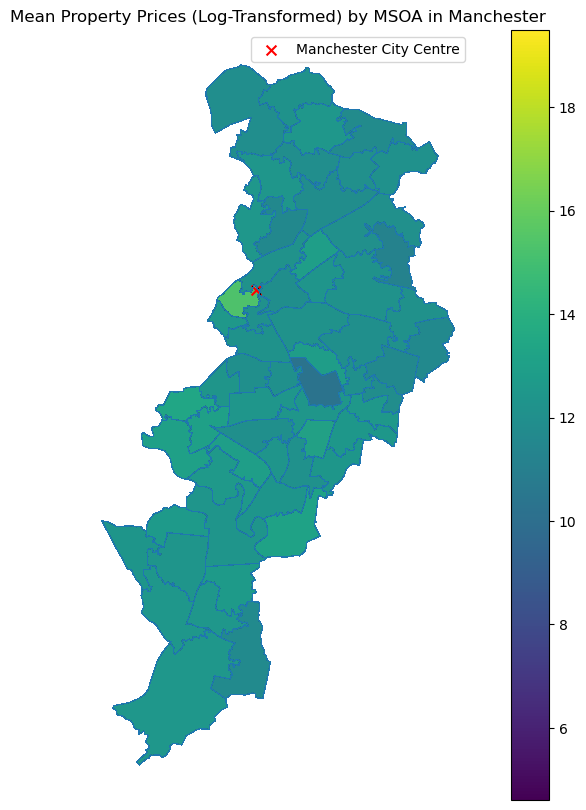

In [78]:
# Mapping property prices

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='log_price', ax=ax, legend=True, missing_kwds={'color': 'lightgrey', 'label': 'Missing'}, alpha=0.9)
gdf_centre.plot(ax=ax, color='red', markersize=50, marker='x', label='Manchester City Centre')
gdf.boundary.plot(ax=ax, linewidth=0.2)
ax.legend()
ax.set_title('Mean Property Prices (Log-Transformed) by MSOA in Manchester')
ax.set_axis_off()
plt.show()

The map above illustrates that property prices can cluster in certain areas, especially near the city centre.

### Mean Ofsted Score by MSOA
The map below illustrates the mean education quality for each MSOA in Manchester, where a lower score means better education quality.

C:\Users\Nitro\AppData\Local\Temp\ipykernel_45244\459433820.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


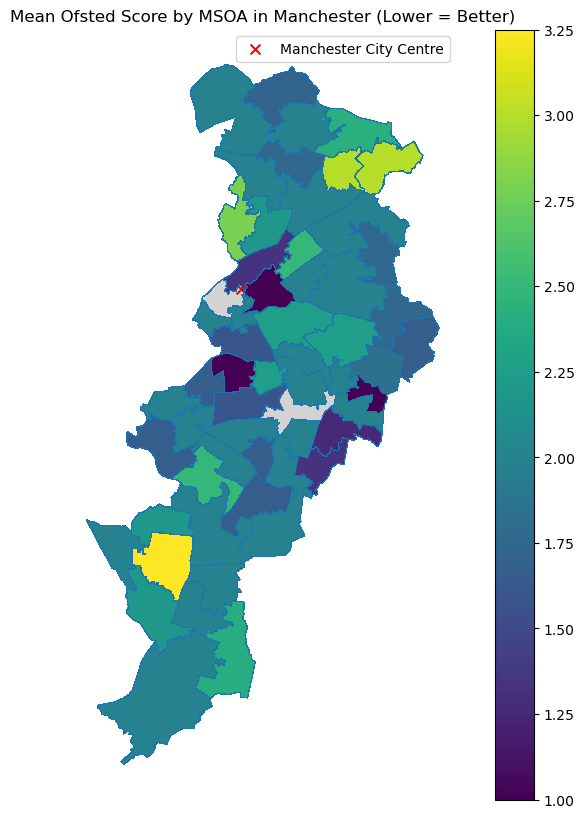

In [79]:
# Mapping education quality

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='msoa_ofsted_score', ax=ax, legend=True, missing_kwds={'color': 'lightgrey', 'label': 'Missing'}, alpha=0.9)
gdf_centre.plot(ax=ax, color='red', markersize=50, marker='x', label='Manchester City Centre')
gdf.boundary.plot(ax=ax, linewidth=0.2)
ax.legend()
ax.set_title('Mean Ofsted Score by MSOA in Manchester (Lower = Better)')
ax.set_axis_off()
plt.show()

The map above illustrates that the more outstanding schools seem to be clustering relatively near to the city centre. Overall, the map demonstrates wide spatial variation of education quality across Manchester with certain patterns such as clustering in some areas, and that there may be wider patterns to pay attention to that relate to education quality in Manchester.

### Mean IMD Rank by MSOA
The map below illustrates the mean socioeconomic deprivation levels for each MSOA in Manchester, where a higher rank means less deprivation.

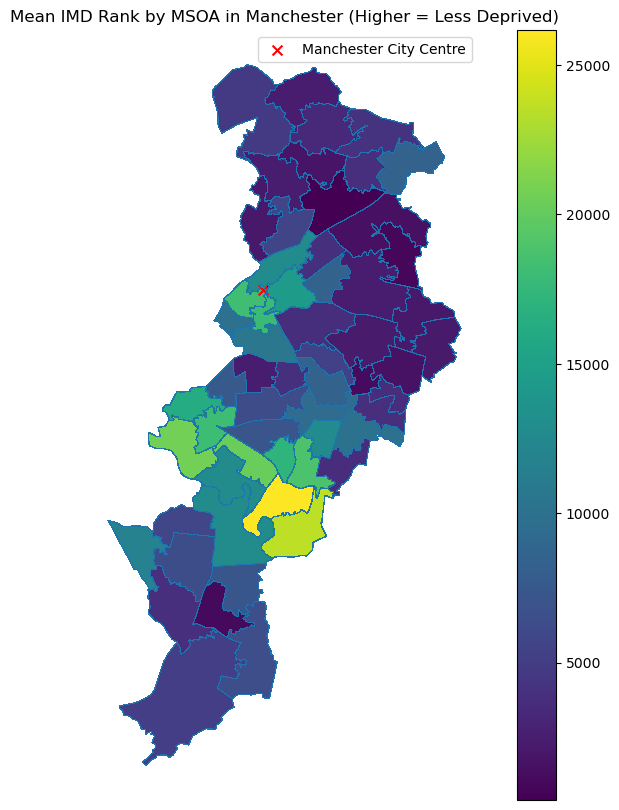

In [80]:
# Mapping IMD Ranks

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='msoa_imd_rank', ax=ax, legend=True, missing_kwds={'color': 'lightgrey', 'label': 'Missing'}, alpha=0.9)
gdf_centre.plot(ax=ax, color='red', markersize=50, marker='x', label='Manchester City Centre')
gdf.boundary.plot(ax=ax, linewidth=0.2)
ax.legend()
ax.set_title('Mean IMD Rank by MSOA in Manchester (Higher = Less Deprived)')
ax.set_axis_off()
plt.show()

The map above illustrates that the most-deprived areas in Manchester are clustered in certain areas, one of the notable and larger areas being somewhat close to the city centre. Furthermore, the least-deprived areas are also clustered in certain areas, generally relatively near to the city centre. The city centre itself and the surrounding areas very close to it can be considered to be moderately-deprived. This map appears to be consistent with the findings from the first map about property prices. Some areas, especially the least-deprived, correspond to areas with higher property prices in the first map.

# Model Specification
This section essentially covers the overview of the modelling phase, including the model used, variables involved, and how interpretations will be made.

## Modelling Framework
For this study on exploring the relationship between property prices and education quality in Manchester, multiple linear regression will be the model of choice. This is due to the variables involved being continuous and numeric, as well as the aim of the project being more focused on inference on the relationship rather than the prediction of property prices.

## Dependent Variable
In this model, the dependent variable is property prices in Manchester, which have also undergone logarithmic transformation to stabilise the distribution of the values and mitigate right-skewness shown by the raw data. This also enables regression coefficients to be interpreted roughly as the percentage of change in property price.

## Main Independent Variable
The main independent variable in the model is education quality in Manchester, measured by the mean Ofsted "Overall Effectiveness" score from school inspections within respective MSOAs, where a lower score means better education quality in that respective MSOA. Aggregating education quality to the mean for each MSOA will provide a single continuous MSOA-level education quality value, due to MSOAs being large in size and will therefore typically contain multiple schools.

Additionally, as observed previously, some education quality records are missing which is most likely to be due to some MSOAs not having any valid school inspection data. Therefore, another model will be created - which will be addressed in the next subsection - focusing on the effect of school presence on property prices (rather than the relationship between education quality and property prices) as a "control"/side model.

## Control Variables
To reduce confounding in the model, two control variables will be introduced: MSOA-level socioeconomic deprivation levels and distance from the property to the city centre. The former is measured by the mean IMD rank for the respective MSOA, where a higher rank means a less-deprived area in Manchester.

## Models
This project will involve two log-linear multiple regression models: a main model that focuses on the relationship between education quality and property prices in Manchester, and a side model focusing on the effect of school presence on them.

### Model 1: Education Quality in School-Present Areas
This model will be the main model of this project, focusing on the relationship between education quality and property prices in Manchester, given that the respective MSOA has schools and their valid inspection data. Below outlines the details of this model.

$$
\log(\text{PropertyPrice}_i) =
\beta_0 +
\beta_1 \text{EducationQuality}_i +
\beta_2 \text{IMDRank}_i +
\beta_3 \text{DistanceToCityCentre}_i +
\varepsilon_i
$$

Where
- $\text{EducationQuality}_i$: Education quality, measured by the mean Ofsted score in the MSOA where lower scores mean better education quality

### Model 2: School Presence
This model is a "control"/side model in this project, focusing on the effect of the property's respective MSOA having schools and their valid inspection data on their price instead. Below outlines the details of this model.

$$
\log(\text{PropertyPrice}_i) =
\beta_0 +
\beta_1 \text{NoSchoolMSOA}_i +
\beta_2 \text{IMDRank}_i +
\beta_3 \text{DistanceToCityCentre}_i +
\varepsilon_i
$$

Where
- $\text{NoSchoolMSOA}_i$: A binary indicator of school presence in the MSOA, where 1 means there are no schools and/or their valid inspection data and 0 means otherwise

In both models,
- $\log(\text{PropertyPrice}_i)$: Log-transformed property price
- $\beta_0$: Expected property price when all other variables are zero, also known as the intercept
- $\text{IMDRank}_i$: The area's average socioeconomic deprivation level, measured by the mean IMD rank in the MSOA where higher ranks mean less-deprived areas
- $\text{DistanceToCityCentre}_i$: Distance from the property to the city centre
- $\varepsilon_i$: Any other variables not included in the model that also affects property prices, also known as the error term

## Interpretation of Coefficients
For this log-linear multiple regression framework, the coefficients will be interpreted as the rough percentage of change in property price from each one-unit increase in each independent variable.

## Scope of Interpretation
Due to the nature of the study being observational and conducted at a relatively large area level (MSOA), the interpretation of relationships in this project will be as associations instead of direct causal effects. Additionally, results and recommendations that involve the education quality variable applies only to MSOAs with valid school inspection data and/or the presence of schools themselves, and should therefore not be generalised as outcomes for all MSOAs in Manchester.

# Assumption Checks
This section will focus on examining the diagnostics to check for four main assumptions of linear regression before modelling: Linearity, Normality, Homoscedasticity, and Multicolinearity. This will help ensure that the regression coefficients in the modelling results are valid.

## Model Estimation for Diagnostics
To examine the models' diagnostics for the assumptions specified earlier, the fitted values and residuals of each model will be required. Therefore, they need to be fitted beforehand to obtain these values.

In [81]:
# Filtering columns in df_final associated with each of the specified models

df_model = df_final[['log_price', 'no_school_msoa', 'msoa_ofsted_score', 'msoa_imd_rank', 'distance_to_city_centre_km']]
df_model_education_quality = df_model.dropna(subset=['msoa_ofsted_score'])
df_model_education_quality = df_model_education_quality.drop('no_school_msoa', axis=1)
df_model_school_presence = df_model.drop('msoa_ofsted_score', axis=1)

In [82]:
# Fitting Model 1 to obtain fitted values and residuals

X1 = df_model_education_quality.drop('log_price', axis=1)
X1 = sm.add_constant(X1)
y1 = df_model_education_quality['log_price']

model_education_quality = sm.OLS(y1, X1).fit()

fitted_education_quality = model_education_quality.fittedvalues
residuals_education_quality = model_education_quality.resid

In [83]:
# Fitting Model 2 to obtain fitted values and residuals

X2 = df_model_school_presence.drop('log_price', axis=1)
X2 = sm.add_constant(X2)
y2 = df_model_school_presence['log_price']

model_school_presence = sm.OLS(y2, X2).fit()

fitted_school_presence = model_school_presence.fittedvalues
residuals_school_presence = model_school_presence.resid

## Running Diagnostics for Assumption Checks
After obtaining fitted values and residuals for each model, each assumption will be examined to ensure the validity of the results. Below outlines the description for each assumption.
- **Linearity:** The relationship between each independent variable and the dependent variable is linear.
- **Normality:** The residuals (also known as the error terms) are roughly normally-distributed.
- **Homoscedasticity:** The spread of residuals is consistent across all independent variable values.
- **Multicolinearity:** Independent variables are not strongly correlated with one another.

In [84]:
# Function to run diagnostics for assumption checks

def run_diagnostics(model, X, model_title):
    fitted = model.fittedvalues
    influence = model.get_influence()
    std_residuals = influence.resid_studentized_internal

    # Checking Linearity
    sns.scatterplot(x=fitted, y=std_residuals, alpha=0.4)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Studentised Residuals')
    plt.title(f'{model_title}: Fitted Values vs. Studentised Residuals')
    plt.show()

    # Checking Normality
    sm.qqplot(std_residuals, line='45')
    plt.title(f'{model_title}: Studentised Residuals Q-Q Plot')
    plt.show()

    # Checking Heteroscedasticitiy
    sns.scatterplot(x=fitted, y=np.abs(std_residuals), alpha=0.4)
    plt.xlabel('Fitted Values')
    plt.ylabel('Studentised Residuals (Absolute)')
    plt.title(f'{model_title}: Scale-Location Plot')
    plt.show()

    # Checking Multicolinearity
    vif = pd.DataFrame({
        'Variable': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    display(vif)

### Model 1 Assumption Checks
Below are the results of the assumption checks for Model 1 (Education Quality).

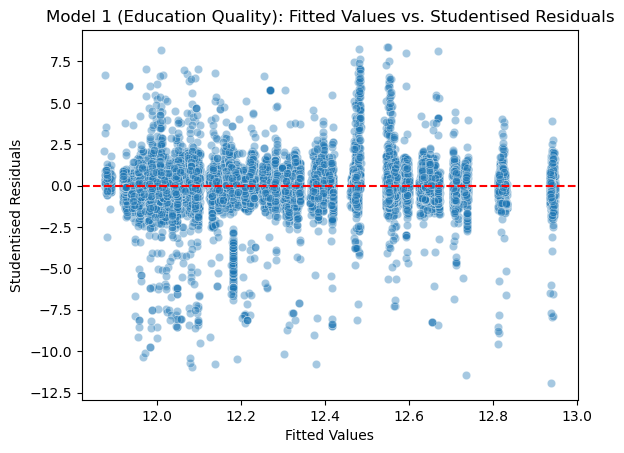

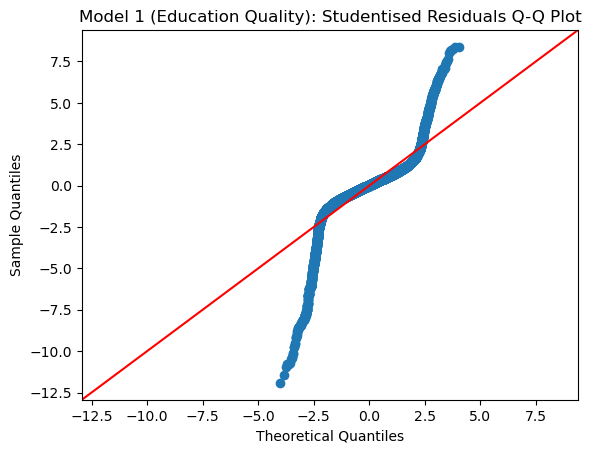

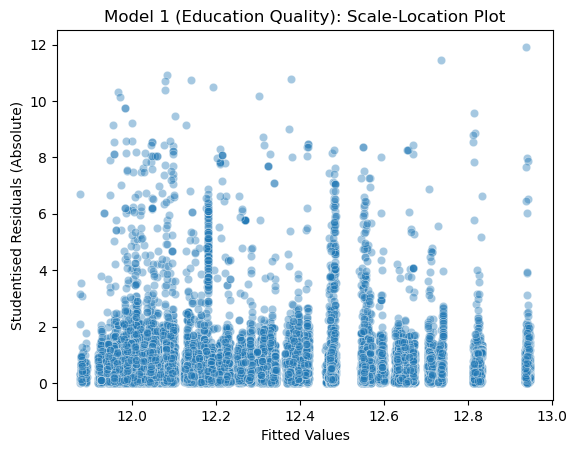

,Variable,VIF
0,const,23.422061
1,msoa_ofsted_score,1.246363
2,msoa_imd_rank,1.077544
3,distance_to_city_centre_km,1.165614


In [85]:
# Running diagnostics on Model 1 for assumption checks

run_diagnostics(model_education_quality, X1, 'Model 1 (Education Quality)')

- **Linearity:** Most of the residuals are clustered near 0, and there are no trends and curves in the plot, hence there is no strong violation of linearity.
- **Normality:** The studentised residuals Q-Q plot illustrates that the tails heavily deviate from normality. However, as the sample used for modelling is large and the aim of this project being inferential, the violation of normality is insufficient to invalidate the modelling results.
- **Homoscedasticity:** The spread of residuals is not completely consistent as some fitted values demonstrate varying residual variance. Therefore, there is some degree of violation of homoscedasticity, but insufficient to invalidate the modelling results as the violations are not extreme.
- **Multicolinearity:** The Variance Inflation Factor (VIF) table demonstrates that the VIF of all independent variables are low, hence there is no strong violation of multicolinearity.

Overall, based on the assumption checks for Model 1 (Education Quality), the modelling results will be considered valid.

### Model 2 Assumption Checks
Below are the results of the assumption checks for Model 2 (School Presence).

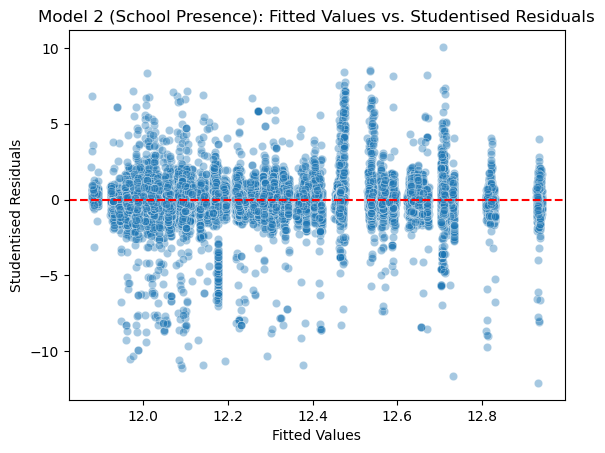

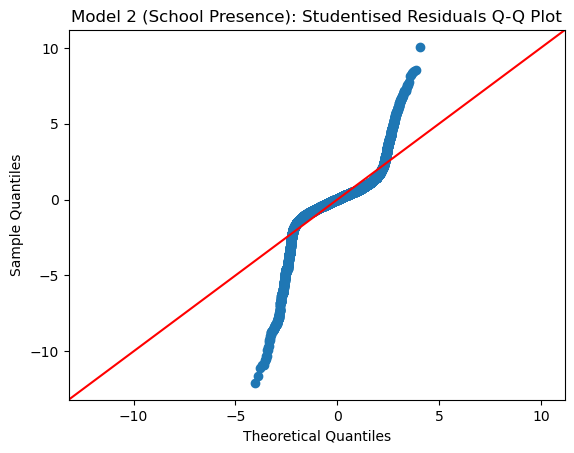

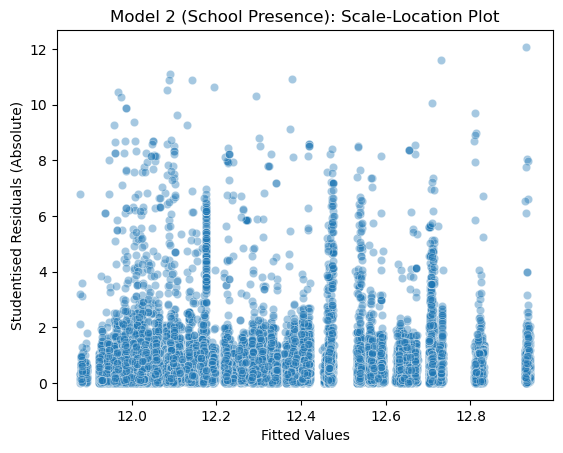

,Variable,VIF
0,const,6.718653
1,no_school_msoa,1.348333
2,msoa_imd_rank,1.182227
3,distance_to_city_centre_km,1.182450


In [86]:
# Running diagnostics on Model 2 for assumption checks

run_diagnostics(model_school_presence, X2, 'Model 2 (School Presence)')

- **Linearity:** Most of the residuals are clustered near 0, and there are no trends and curves in the plot, hence there is no strong violation of linearity.
- **Normality:** The studentised residuals Q-Q plot illustrates that the tails heavily deviate from normality. However, as the sample used for modelling is large and the aim of this project being inferential, the violation of normality is insufficient to invalidate the modelling results.
- **Homoscedasticity:** The spread of residuals is not completely consistent as some fitted values demonstrate varying residual variance. Therefore, there is some degree of violation of homoscedasticity, but insufficient to invalidate the modelling results as the violations are not extreme.
- **Multicolinearity:** The Variance Inflation Factor (VIF) table demonstrates that the VIF of all independent variables are low, hence there is no strong violation of multicolinearity.

Overall, based on the assumption checks for Model 2 (School Presence), the modelling results will be considered valid.

# Results
This section involves the final modelling phase, which includes the interpretation of regression coefficients to assess the relationship between property prices in Manchester and education quality, and other control variables such as socioeconomic deprivation and proximity to the city centre.

- **Model 1** will explore the relationship between education quality and property prices, thus being the main model of this project.
- **Model 2** will focus more on the effect of school presence on property prices as a side model.

## Final Model Fitting
The models will be fitted one last time to report results.

In [87]:
# Fitting the models for final reporting

model_education_quality = sm.OLS(y1, X1).fit()
model_school_presence = sm.OLS(y2, X2).fit()

## Model 1 (Main): Education Quality for Areas with Schools
The regression table for Model 1, including coefficients and p-values, will be used to interpret the associations of each independent variable and property prices.

In [88]:
# Displaying the regression table for Model 1

results_education_quality = pd.DataFrame({
    'Coefficient': model_education_quality.params,
    'Standard Error': model_education_quality.bse,
    'P-Value': model_education_quality.pvalues
})

results_education_quality

,Coefficient,Standard Error,P-Value
const,11.989284,1.788838e-02,0.000000e+00
msoa_ofsted_score,-0.015122,8.676442e-03,8.136725e-02
msoa_imd_rank,0.000040,5.797666e-07,0.000000e+00
distance_to_city_centre_km,-0.011276,1.475526e-03,2.198349e-14


Based on the regression table above, education quality (```msoa_ofsted_score```) has a coefficient of -0.015. This indicates that, given that the other variables are constant, property prices decrease by ~1.5% with every one-unit increase in the MSOA's mean Ofsted score given that higher scores mean lower education quality. Therefore, higher education quality can be associated with higher property prices. However, once control variables are considered, this association is not statistically significant at 5%, shown by the p-value of ~0.081.

The control variables of socioeconomic deprivation (```msoa_imd_rank```) and proximity to the city centre (```distance_to_city_centre_km```) both demonstrate positive associations with property prices where less-deprived areas (higher IMD ranks) tend to have higher property prices, and properties closer to the city centre are associated with having higher prices. Additionally, both variables are strongly statistically-significant as observed from their very low p-levels. These findings align with previous discoveries in the Exploratory Data Analysis phase.

To conclude, these results point out that education quality is associated with property prices in the expected direction (negative), however this particular association appears to be weaker than the associations with socioeconomic deprivation and centre-proximity variables. This suggests that access to schools, the neighbourhood, and geographic location of the property may have a stronger effect on property prices than the minor differences in education quality of each school.

## Model 2: School Presence
a

In [89]:
# Displaying the regression table for Model 2

results_school_presence = pd.DataFrame({
    'Coefficient': model_school_presence.params,
    'Standard Error': model_school_presence.bse,
    'P-Value': model_school_presence.pvalues
})

results_school_presence

,Coefficient,Standard Error,P-Value
const,11.962233,8.881269e-03,0.000000e+00
no_school_msoa,0.021529,1.243078e-02,8.330128e-02
msoa_imd_rank,0.000040,5.451128e-07,0.000000e+00
distance_to_city_centre_km,-0.011483,1.333501e-03,7.494323e-18


a

## Main Model Fit
The adjusted r-squared value for Model 1 is also examined and used to assess how well the model explains the variation in log-transformed property prices.

In [90]:
# Obtaining the adjusted r-squared for Model 1

model_education_quality.rsquared_adj

0.13537364331625024

a

## Model Comparison
a